# Matching LDA organizations with IRS records

The analysis connects organizations reported in LDA lobbying filings with IRS Form 990 records stored as Parquet files in S3.

Organizations are evaluated separately according to their role in each filing: client, registrant, or affiliate. Names are normalized before exact and Jaro-Winkler comparisons are run against the IRS organization table.

Match strength is based on the available supporting evidence:

- name
- name and state
- name, state, and 5-digit ZIP

These links should be treated as review candidates, not confirmed identities.

In [46]:
from pathlib import Path
import duckdb

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
PARQUET_BASE = "s3://irs-990-263839540825-us-east-2-an/parquet_updated"
AWS_REGION = "us-east-2"

conn = duckdb.connect(database=":memory:")
conn.execute("INSTALL httpfs; LOAD httpfs;")
conn.execute(f"""
    CREATE SECRET s3_access (
        TYPE s3,
        PROVIDER credential_chain,
        REGION '{AWS_REGION}'
    )
""")

for table in (
    "organizations",
    "irs_master",
    "irs990_filings",
    "irs990_filing_related_orgs",
    "irs990_filing_527_orgs",
    "lda_filings",
    "entity_observations",
):
    conn.execute(f"""
        CREATE OR REPLACE VIEW {table} AS
        SELECT *
        FROM read_parquet(
            '{PARQUET_BASE}/{table}/*.parquet',
            union_by_name = true
        )
    """)

def q(sql):
    return conn.execute(sql).df()

coverage = q("""
SELECT 1 AS sort_order, 'Form 990 e-file organization EINs' AS metric,
       COUNT(DISTINCT ein) AS value
FROM organizations
UNION ALL
SELECT 2, 'EINs in current loaded IRS master extract', COUNT(DISTINCT ein)
FROM irs_master
UNION ALL
SELECT 3, 'Current IRS master EINs with state', COUNT(DISTINCT ein)
FROM irs_master
WHERE NULLIF(TRIM(state), '') IS NOT NULL
UNION ALL
SELECT 4, 'Form 990 filing EINs with filing state', COUNT(DISTINCT ein)
FROM irs990_filings
WHERE NULLIF(TRIM(CAST(filer_state AS VARCHAR)), '') IS NOT NULL
UNION ALL
SELECT 5, 'Schedule R related-org EINs with state',
       COUNT(DISTINCT ein)
FROM irs990_filing_related_orgs
WHERE NULLIF(TRIM(ein), '') IS NOT NULL
  AND NULLIF(TRIM(state_code), '') IS NOT NULL
UNION ALL
SELECT 6, '527-org EINs with state', COUNT(DISTINCT ein)
FROM irs990_filing_527_orgs
WHERE NULLIF(TRIM(ein), '') IS NOT NULL
  AND NULLIF(TRIM(state_code), '') IS NOT NULL
UNION ALL
SELECT 7, 'LDA filings', COUNT(*) FROM lda_filings
UNION ALL
SELECT 8, 'LDA filings with client state', COUNT(*)
FROM lda_filings
WHERE json_valid(raw_json)
  AND NULLIF(TRIM(json_extract_string(raw_json, '$.client.state')), '') IS NOT NULL
UNION ALL
SELECT 9, 'Distinct LDA client IDs',
       COUNT(DISTINCT json_extract_string(raw_json, '$.client.id'))
FROM lda_filings WHERE json_valid(raw_json)
UNION ALL
SELECT 10, 'Distinct LDA client IDs with state',
       COUNT(DISTINCT CASE
           WHEN NULLIF(TRIM(json_extract_string(raw_json, '$.client.state')), '') IS NOT NULL
           THEN json_extract_string(raw_json, '$.client.id') END)
FROM lda_filings WHERE json_valid(raw_json)
ORDER BY sort_order
""").drop(columns="sort_order")

print(f"DuckDB reading updated Parquet from: {PARQUET_BASE}")
coverage.style.format({"value": "{:,.0f}"})

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

DuckDB reading updated Parquet from: s3://irs-990-263839540825-us-east-2-an/parquet_updated


,metric,value
0,Form 990 e-file organization EINs,"861,081"
1,EINs in current loaded IRS master extract,"279,802"
2,Current IRS master EINs with state,"279,802"
3,Form 990 filing EINs with filing state,"860,890"
4,Schedule R related-org EINs with state,"193,996"
5,527-org EINs with state,"10,530"
6,LDA filings,"192,174"
7,LDA filings with client state,"186,203"
8,Distinct LDA client IDs,"28,790"
9,Distinct LDA client IDs with state,"27,845"


In [47]:
import re as _re

# Shared helpers so the matching cells below don't repeat the same logic:
#   NEAR_NAME_MIN_SIMILARITY - single source of truth for the near-name cutoff
#   norm_org      - org-name normalization matching extract/entities.py
#   name_block_on - blocked Jaro-Winkler join predicate (shared 8-char prefix + length ratio)
#   tier_case     - name / name+state / name+state+zip label from zip_agrees / state_agrees
NEAR_NAME_MIN_SIMILARITY = 0.85

_NOISE = {
    "inc", "incorporated", "llc", "lp", "llp", "corp", "corporation",
    "the", "of", "and", "for", "a", "an", "pac", "cmte", "association", "committee", "fund", "foundation", "trust", "club"
}

def _norm_org(name):
    if not name:
        return ""
    tokens = _re.sub(r"[^a-z0-9\s]", " ", name.lower()).split()
    return " ".join(t for t in tokens if t not in _NOISE)

try:
    conn.create_function("norm_org", _norm_org, ["VARCHAR"], "VARCHAR")
except Exception:
    pass  # already registered in this kernel

def name_block_on(a, b):
    """Blocking predicate for near-name joins: shared 8-char prefix and >=60% length ratio."""
    return (
        f"LEFT({a}, 8) = LEFT({b}, 8)\n"
        f"     AND LEAST(LENGTH({a}), LENGTH({b}))::DOUBLE\n"
        f"         / GREATEST(LENGTH({a}), LENGTH({b})) >= 0.60"
    )

def tier_case(prefix="name"):
    """Strongest-evidence label from the zip_agrees / state_agrees booleans."""
    return (
        "CASE "
        f"WHEN zip_agrees THEN '{prefix} + state + zip' "
        f"WHEN state_agrees THEN '{prefix} + state' "
        f"ELSE '{prefix} only' END"
    )


In [48]:
# IRS EIN-level entities: name, normalized name, and best-available state
# (latest Form 990 filing state; else BMF master; else Schedule R; else 527).
conn.execute("""
CREATE OR REPLACE TEMP TABLE irs_entities AS
WITH ranked_filing_states AS (
    SELECT
        ein,
        UPPER(NULLIF(TRIM(CAST(filer_state AS VARCHAR)), '')) AS filing_state,
        ROW_NUMBER() OVER (
            PARTITION BY ein
            ORDER BY
                COALESCE(return_timestamp, tax_period_end_date, CAST(tax_year AS VARCHAR)) DESC,
                filing_id DESC
        ) AS state_recency
    FROM irs990_filings
    WHERE NULLIF(TRIM(CAST(filer_state AS VARCHAR)), '') IS NOT NULL
), filing_states AS (
    SELECT ein, filing_state FROM ranked_filing_states WHERE state_recency = 1
), related_states AS (
    SELECT ein, mode(UPPER(TRIM(state_code))) AS related_state
    FROM irs990_filing_related_orgs
    WHERE NULLIF(TRIM(ein), '') IS NOT NULL AND NULLIF(TRIM(state_code), '') IS NOT NULL
    GROUP BY ein
), p527_states AS (
    SELECT ein, mode(UPPER(TRIM(state_code))) AS p527_state
    FROM irs990_filing_527_orgs
    WHERE NULLIF(TRIM(ein), '') IS NOT NULL AND NULLIF(TRIM(state_code), '') IS NOT NULL
    GROUP BY ein
)
SELECT
    organization.ein,
    organization.current_name AS irs_name,
    organization.normalized_name,
    COALESCE(
        filing.filing_state,
        UPPER(NULLIF(TRIM(master.state), '')),
        related.related_state,
        p527.p527_state
    ) AS irs_state
FROM organizations AS organization
LEFT JOIN filing_states AS filing USING (ein)
LEFT JOIN irs_master AS master USING (ein)
LEFT JOIN related_states AS related USING (ein)
LEFT JOIN p527_states AS p527 USING (ein)
WHERE organization.normalized_name IS NOT NULL
  AND organization.normalized_name <> ''
""")

print("IRS entities:", f"{q('SELECT COUNT(*) AS n FROM irs_entities').iloc[0]['n']:,}")

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

IRS entities: 861,079


## Building the LDA organization list

Filings are retained when they report lobbying income or expenses. One organization record is created for each role: client, registrant, or affiliate.

LDA client records do not normally expose ZIP codes through the API. The `client_zip.csv` file in S3 contains addresses recovered from historical filing HTML. Both address slots are normalized to 5-digit U.S. ZIP codes and validated against the filing's client state or principal-place-of-business state. A stable ZIP is then selected for each client ID and state using the most frequently observed value. When two ZIPs have equal support, the lower ZIP is selected deterministically.

The recovered client-state map is applied to the fee-bearing filing cohort. Existing self-filing registrant ZIPs remain as a fallback when no state-consistent recovered ZIP is available. This prevents ZIPs from being transferred across clients or states while increasing the number of client organizations that can be checked using name, state, and ZIP agreement.

In [ ]:
# Build a state-validated client ZIP map from all recovered filing addresses.
conn.execute(f"""
CREATE OR REPLACE TEMP TABLE recovered_client_zip AS
WITH all_client_filings AS (
    SELECT
        filing_uuid,
        json_extract_string(raw_json, '$.client.id') AS client_id,
        UPPER(NULLIF(TRIM(json_extract_string(raw_json, '$.client.state')), '')) AS client_state,
        UPPER(NULLIF(TRIM(json_extract_string(raw_json, '$.client.ppb_state')), '')) AS client_ppb_state
    FROM lda_filings
    WHERE json_valid(raw_json)
), recovery_source AS MATERIALIZED (
    SELECT *
    FROM read_csv_auto(
        's3://irs-990-263839540825-us-east-2-an/client_zip.csv',
        header=true,
        all_varchar=true
    )
), recovery_addresses AS (
    SELECT
        source.filing_uuid,
        source.client_id,
        UPPER(NULLIF(TRIM(address.state), '')) AS recovered_state,
        NULLIF(regexp_extract(TRIM(address.zip), '([0-9]{{5}})', 1), '') AS recovered_zip5,
        UPPER(NULLIF(TRIM(address.country), '')) AS recovered_country
    FROM recovery_source AS source,
    UNNEST([
        STRUCT_PACK(state := source.state_1, zip := source.zip_1, country := source.country_1),
        STRUCT_PACK(state := source.state_2, zip := source.zip_2, country := source.country_2)
    ]) AS unpacked(address)
), validated AS (
    SELECT
        filing.client_id,
        address.recovered_state,
        address.recovered_zip5
    FROM all_client_filings AS filing
    JOIN recovery_addresses AS address
      ON address.filing_uuid = filing.filing_uuid
     AND address.client_id = filing.client_id
     AND address.recovered_state IN (filing.client_state, filing.client_ppb_state)
    WHERE address.recovered_zip5 IS NOT NULL
      AND COALESCE(address.recovered_country, 'USA') IN ('USA', 'US', 'UNITED STATES')
), zip_frequency AS (
    SELECT
        client_id,
        recovered_state,
        recovered_zip5,
        COUNT(*) AS observations
    FROM validated
    GROUP BY client_id, recovered_state, recovered_zip5
), ranked AS (
    SELECT *,
           ROW_NUMBER() OVER (
               PARTITION BY client_id, recovered_state
               ORDER BY observations DESC, recovered_zip5
           ) AS zip_rank
    FROM zip_frequency
)
SELECT client_id, recovered_state, recovered_zip5, observations
FROM ranked
WHERE zip_rank = 1
""")

conn.execute("""
CREATE OR REPLACE TEMP TABLE lda_fee_filings AS
SELECT
    filing_uuid,
    json_extract_string(raw_json, '$.client.id')   AS client_id,
    json_extract_string(raw_json, '$.client.name') AS client_name,
    UPPER(NULLIF(TRIM(json_extract_string(raw_json, '$.client.state')), '')) AS client_state,
    UPPER(NULLIF(TRIM(json_extract_string(raw_json, '$.client.ppb_state')), '')) AS client_ppb_state,
    json_extract_string(raw_json, '$.registrant.name') AS registrant_name,
    UPPER(NULLIF(TRIM(json_extract_string(raw_json, '$.registrant_state')), '')) AS registrant_state,
    LEFT(NULLIF(TRIM(json_extract_string(raw_json, '$.registrant_zip')), ''), 5) AS registrant_zip5,
    raw_json
FROM lda_filings
WHERE json_valid(raw_json)
  AND (COALESCE(income, 0) > 0 OR COALESCE(expenses, 0) > 0)
""")

# One candidate per (role, org) with the org's normalized name and available location.
# The historical client-state recovery map is preferred, followed by the existing
# self-filing fallback. State agreement is required before any recovered ZIP is used.
conn.execute("""
CREATE OR REPLACE TEMP TABLE lda_org_candidates AS
WITH self_filed_zip AS (
    SELECT norm_org(client_name) AS client_norm,
           registrant_state AS self_state,
           mode(registrant_zip5) AS self_zip5
    FROM lda_fee_filings
    WHERE norm_org(client_name) = norm_org(registrant_name)
      AND registrant_zip5 IS NOT NULL
      AND registrant_state IS NOT NULL
    GROUP BY norm_org(client_name), registrant_state
), client_role AS (
    SELECT
        'client' AS role,
        filing.client_id AS lda_key,
        filing.client_name AS lda_name,
        norm_org(filing.client_name) AS normalized_name,
        filing.client_state AS lda_state,
        filing.client_ppb_state AS lda_ppb_state,
        COALESCE(
            state_zip.recovered_zip5,
            ppb_zip.recovered_zip5,
            CASE WHEN norm_org(filing.client_name) = norm_org(filing.registrant_name)
                 THEN filing.registrant_zip5 END,
            self_zip.self_zip5
        ) AS lda_zip,
        CASE
            WHEN state_zip.recovered_zip5 IS NOT NULL
              OR ppb_zip.recovered_zip5 IS NOT NULL THEN 'client_zip.csv'
            WHEN norm_org(filing.client_name) = norm_org(filing.registrant_name)
                 AND filing.registrant_zip5 IS NOT NULL THEN 'self-filing registrant'
            WHEN self_zip.self_zip5 IS NOT NULL THEN 'self-filing fallback'
        END AS lda_zip_source
    FROM lda_fee_filings AS filing
    LEFT JOIN recovered_client_zip AS state_zip
      ON state_zip.client_id = filing.client_id
     AND state_zip.recovered_state = filing.client_state
    LEFT JOIN recovered_client_zip AS ppb_zip
      ON ppb_zip.client_id = filing.client_id
     AND ppb_zip.recovered_state = filing.client_ppb_state
     AND ppb_zip.recovered_state IS DISTINCT FROM filing.client_state
    LEFT JOIN self_filed_zip AS self_zip
      ON self_zip.client_norm = norm_org(filing.client_name)
     AND self_zip.self_state IN (filing.client_state, filing.client_ppb_state)
), registrant_role AS (
    SELECT
        'registrant',
        registrant_name,
        registrant_name,
        norm_org(registrant_name),
        registrant_state,
        NULL,
        registrant_zip5,
        'registrant filing'
    FROM lda_fee_filings
), affiliate_role AS (
    SELECT
        'affiliate',
        json_extract_string(affiliate.value, '$.name'),
        json_extract_string(affiliate.value, '$.name'),
        norm_org(json_extract_string(affiliate.value, '$.name')),
        UPPER(NULLIF(TRIM(json_extract_string(affiliate.value, '$.state')), '')),
        UPPER(NULLIF(TRIM(json_extract_string(affiliate.value, '$.ppb_state')), '')),
        LEFT(NULLIF(TRIM(json_extract_string(affiliate.value, '$.zip')), ''), 5),
        'affiliate filing'
    FROM lda_fee_filings,
         json_each(json_extract(raw_json, '$.affiliated_organizations')) AS affiliate
)
SELECT DISTINCT *
FROM (
    SELECT * FROM client_role
    UNION ALL SELECT * FROM registrant_role
    UNION ALL SELECT * FROM affiliate_role
) AS all_roles
WHERE normalized_name IS NOT NULL
  AND LEN(STRING_SPLIT(normalized_name, ' ')) >= 2
""")

candidate_counts = q("""
SELECT role,
       COUNT(*) AS candidate_rows,
       COUNT(DISTINCT lda_key) AS distinct_orgs,
       COUNT(DISTINCT lda_key) FILTER (WHERE lda_zip IS NOT NULL) AS orgs_with_zip,
       COUNT(DISTINCT lda_key) FILTER (WHERE lda_zip_source = 'client_zip.csv') AS orgs_with_recovered_zip
FROM lda_org_candidates
GROUP BY role
ORDER BY role
""")
candidate_counts.style.format({
    "candidate_rows": "{:,.0f}",
    "distinct_orgs": "{:,.0f}",
    "orgs_with_zip": "{:,.0f}",
    "orgs_with_recovered_zip": "{:,.0f}",
})

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

In [81]:
# IRS entities with a 5-digit ZIP from their most recent filing, for ZIP agreement.
conn.execute("""
CREATE OR REPLACE TEMP TABLE irs_entities_addr AS
WITH latest AS (
    SELECT
        ein,
        LEFT(NULLIF(TRIM(CAST(filer_zip AS VARCHAR)), ''), 5) AS filer_zip5,
        ROW_NUMBER() OVER (
            PARTITION BY ein
            ORDER BY COALESCE(return_timestamp, tax_period_end_date, CAST(tax_year AS VARCHAR)) DESC,
                     filing_id DESC
        ) AS rn
    FROM irs990_filings
    WHERE NULLIF(TRIM(CAST(filer_zip AS VARCHAR)), '') IS NOT NULL
)
SELECT irs.ein, irs.irs_name, irs.normalized_name, irs.irs_state,
       latest.filer_zip5 AS irs_zip
FROM irs_entities AS irs
LEFT JOIN latest ON latest.ein = irs.ein AND latest.rn = 1
""")

conn.execute("""
CREATE OR REPLACE TEMP TABLE role_matches AS
SELECT
    cand.role,
    cand.lda_key,
    cand.lda_name,
    cand.normalized_name,
    cand.lda_state,
    cand.lda_ppb_state,
    cand.lda_zip,
    cand.lda_zip_source,
    irs.ein,
    irs.irs_name,
    irs.irs_state,
    irs.irs_zip,
    (irs.irs_state IN (cand.lda_state, cand.lda_ppb_state)
        AND irs.irs_state IS NOT NULL) AS state_agrees,
    (cand.lda_zip IS NOT NULL AND cand.lda_zip = irs.irs_zip) AS zip_agrees
FROM lda_org_candidates AS cand
JOIN irs_entities_addr AS irs USING (normalized_name)
""")

role_match_summary = q("""
SELECT
    role,
    COUNT(DISTINCT lda_key) AS matched_orgs,
    COUNT(DISTINCT ein) AS irs_eins,
    COUNT(DISTINCT lda_key) FILTER (WHERE state_agrees) AS state_agree_orgs,
    COUNT(DISTINCT lda_key) FILTER (WHERE zip_agrees) AS zip_agree_orgs,
    COUNT(DISTINCT lda_key) FILTER (
        WHERE zip_agrees AND lda_zip_source = 'client_zip.csv'
    ) AS recovered_zip_agree_orgs
FROM role_matches
GROUP BY role
ORDER BY role
""")
role_match_summary.style.format({
    "matched_orgs": "{:,.0f}",
    "irs_eins": "{:,.0f}",
    "state_agree_orgs": "{:,.0f}",
    "zip_agree_orgs": "{:,.0f}",
    "recovered_zip_agree_orgs": "{:,.0f}",
})

,role,matched_orgs,irs_eins,state_agree_orgs,zip_agree_orgs,recovered_zip_agree_orgs
0,affiliate,25,25,23,19,0
1,client,"3,189","4,039","2,688","1,446",579
2,registrant,653,"1,861",557,503,0


## Near-name matching by role

The `role_matches` table contains exact normalized-name matches. This section adds near-name candidates for clients, registrants, and affiliates using the following rules:

- the first eight normalized characters must match
- the shorter name must be at least 60% of the longer name
- Jaro-Winkler similarity must be at least `NEAR_NAME_MIN_SIMILARITY` (0.85)
- exact matches are excluded because they already appear in `role_matches`

State (`state` or `ppb_state`) and 5-digit ZIP agreement are then added as supporting evidence. Near-name matches without geographic agreement remain candidates for manual review.

In [82]:
# Near-name role matching: same block + Jaro-Winkler rules, then state / ZIP agreement.
# Excludes exact normalized-name equality (already covered by role_matches).
conn.execute(f"""
CREATE OR REPLACE TEMP TABLE role_near_matches AS
WITH blocked AS (
    SELECT
        cand.role,
        cand.lda_key,
        cand.lda_name,
        cand.normalized_name AS lda_normalized_name,
        cand.lda_state,
        cand.lda_ppb_state,
        cand.lda_zip,
        cand.lda_zip_source,
        irs.ein,
        irs.irs_name,
        irs.normalized_name AS irs_normalized_name,
        irs.irs_state,
        irs.irs_zip,
        jaro_winkler_similarity(cand.normalized_name, irs.normalized_name) AS name_similarity
    FROM lda_org_candidates AS cand
    JOIN irs_entities_addr AS irs
      ON {name_block_on('cand.normalized_name', 'irs.normalized_name')}
     AND cand.normalized_name <> irs.normalized_name
    WHERE jaro_winkler_similarity(cand.normalized_name, irs.normalized_name)
          >= {NEAR_NAME_MIN_SIMILARITY}
)
SELECT *,
    (irs_state IN (lda_state, lda_ppb_state) AND irs_state IS NOT NULL) AS state_agrees,
    (lda_zip IS NOT NULL AND lda_zip = irs_zip) AS zip_agrees
FROM blocked
""")

role_near_summary = q(f"""
WITH labeled AS (
    SELECT *, {tier_case('near-name')} AS confidence
    FROM role_near_matches
)
SELECT
    confidence,
    role,
    COUNT(*) AS candidate_links,
    COUNT(DISTINCT lda_key) AS lda_orgs,
    COUNT(DISTINCT ein) AS irs_eins,
    COUNT(DISTINCT lda_key) FILTER (
        WHERE zip_agrees AND lda_zip_source = 'client_zip.csv'
    ) AS recovered_zip_agree_orgs,
    ROUND(AVG(name_similarity), 3) AS avg_similarity
FROM labeled
GROUP BY confidence, role
ORDER BY
    CASE confidence WHEN 'near-name + state + zip' THEN 1
                    WHEN 'near-name + state' THEN 2 ELSE 3 END,
    role
""")
display(role_near_summary.style.format({
    "candidate_links": "{:,.0f}",
    "lda_orgs": "{:,.0f}",
    "irs_eins": "{:,.0f}",
    "recovered_zip_agree_orgs": "{:,.0f}",
    "avg_similarity": "{:.3f}",
}))

,confidence,role,candidate_links,lda_orgs,irs_eins,recovered_zip_agree_orgs,avg_similarity
0,near-name + state + zip,affiliate,128,43,119,0,0.878
1,near-name + state + zip,client,"10,937","2,597","3,467",989,0.876
2,near-name + state + zip,registrant,"4,305",926,"2,190",0,0.874
3,near-name + state,affiliate,"1,322",50,"1,235",0,0.867
4,near-name + state,client,"228,073","7,231","50,991",0,0.867
5,near-name + state,registrant,"43,402","1,240","16,603",0,0.866
6,near-name only,affiliate,"20,028",103,"12,494",0,0.865
7,near-name only,client,"2,149,767","10,137","120,892",0,0.865
8,near-name only,registrant,"570,790","2,195","68,674",0,0.866


In [83]:
# High-confidence LDA<->IRS cohort for the network step.
# One row per (role, org): best EIN at name_similarity >= HIGH_CONF_MIN, tier = name+state+zip else name+state.
HIGH_CONF_MIN = 0.9

conn.execute("""
CREATE OR REPLACE TEMP TABLE all_role_matches AS
SELECT role, lda_key, lda_name, ein, irs_name, 1.0 AS name_similarity,
       lda_state, irs_state, lda_zip, irs_zip, lda_zip_source,
       state_agrees, zip_agrees
FROM role_matches
UNION ALL
SELECT role, lda_key, lda_name, ein, irs_name, name_similarity,
       lda_state, irs_state, lda_zip, irs_zip, lda_zip_source,
       state_agrees, zip_agrees
FROM role_near_matches
""")

conn.execute(f"""
CREATE OR REPLACE TEMP TABLE high_conf_matches AS
WITH ranked AS (
    SELECT role, lda_key, lda_name, ein, irs_name, name_similarity,
           lda_state, irs_state, lda_zip, irs_zip, lda_zip_source, zip_agrees,
           ROW_NUMBER() OVER (
               PARTITION BY role, lda_key
               ORDER BY zip_agrees DESC, state_agrees DESC, name_similarity DESC, ein
           ) AS rn
    FROM all_role_matches
    WHERE name_similarity >= {HIGH_CONF_MIN} AND (state_agrees OR zip_agrees)
)
SELECT role, lda_key, lda_name, ein, irs_name,
       ROUND(name_similarity, 4) AS name_similarity,
       lda_state, irs_state, lda_zip, irs_zip, lda_zip_source,
       CASE WHEN zip_agrees THEN 'name+state+zip' ELSE 'name+state' END AS tier
FROM ranked WHERE rn = 1
""")

high_conf_matches = q("SELECT * FROM high_conf_matches ORDER BY tier, role, lda_name")
print(f"high-confidence matches (similarity >= {HIGH_CONF_MIN}): "
      f"{len(high_conf_matches):,} orgs, {high_conf_matches['ein'].nunique():,} distinct EINs")
print(high_conf_matches.groupby(["tier", "role", "lda_zip_source"], dropna=False).size().to_string())
display(high_conf_matches)

high-confidence matches (similarity >= 0.9): 7,085 orgs, 4,056 distinct EINs
tier            role        lda_zip_source        
name+state      affiliate   affiliate filing            19
                client      client_zip.csv             466
                            self-filing fallback       215
                            self-filing registrant     204
                            NaN                       2528
                registrant  registrant filing          254
name+state+zip  affiliate   affiliate filing            35
                client      client_zip.csv             987
                            self-filing fallback       683
                            self-filing registrant     837
                registrant  registrant filing          857


,role,lda_key,lda_name,ein,irs_name,name_similarity,lda_state,irs_state,lda_zip,irs_zip,lda_zip_source,tier
0,affiliate,AMERICAN EXPRESS,AMERICAN EXPRESS,810817252,AMERICAN PASSAGE INC,0.9096,NY,NY,10285,10510,affiliate filing,name+state
1,affiliate,AMERICAN FOREST FOUNDATION,AMERICAN FOREST FOUNDATION,943031987,AMERICAN FOUNDRY SOCIETY,0.9117,WA,WA,20036,98188,affiliate filing,name+state
2,affiliate,AMERICAN INTERNATIONAL GROUP (AIG),AMERICAN INTERNATIONAL GROUP (AIG),812838839,AMERICAN INTERNATIONAL DEVELOPMENT FOUNDATION INC,0.9032,NY,NY,10038,10013,affiliate filing,name+state
3,affiliate,AMERICAN SOCIETY OF CIVIL ENGINEERS,AMERICAN SOCIETY OF CIVIL ENGINEERS,132798416,AMERICAN SOCIETY OF INTERIOR DESIGNERS,0.9125,DC,DC,20001,20005,affiliate filing,name+state
4,affiliate,AMERICAN SYSTEMS,AMERICAN SYSTEMS,874485625,The American Lyceum,0.9100,VA,VA,20151,20119,affiliate filing,name+state
...,...,...,...,...,...,...,...,...,...,...,...,...
7080,registrant,YALE UNIVERSITY,YALE UNIVERSITY,060646973,Yale University,1.0000,CT,CT,06520,06520,registrant filing,name+state+zip
7081,registrant,YWCA USA,YWCA USA,131624103,YWCA USA INC,1.0000,DC,DC,20005,20005,registrant filing,name+state+zip
7082,registrant,ZERO EMISSION TRANSPORTATION ASSOCIATION,ZERO EMISSION TRANSPORTATION ASSOCIATION,852297985,ZERO EMISSION TRANSPORTATION ASSOC,0.9647,DC,DC,20003,20003,registrant filing,name+state+zip
7083,registrant,ZERO PROSTATE CANCER,ZERO PROSTATE CANCER,593400922,ZERO PROSTATE CANCER,1.0000,VA,VA,22314,22314,registrant filing,name+state+zip


In [84]:
# What downstream data is available for the matched orgs -> inputs for the network step.
for t in ("irs990_filing_grants", "irs990_filing_people", "irs990_filing_related_orgs",
          "irs990_filing_related_org_transactions", "irs990_filing_contractors",
          "irs990_filing_lobbying", "lobbying_bill_links", "lda_lobbying_activities"):
    conn.execute(f"""CREATE OR REPLACE VIEW {t} AS
        SELECT * FROM read_parquet('{PARQUET_BASE}/{t}/*.parquet', union_by_name=true)""")

# Form 990 filings belonging to the matched EINs (filing_id is the join key for filing_* tables).
conn.execute("""
CREATE OR REPLACE TEMP TABLE matched_ein_filings AS
SELECT DISTINCT f.filing_id, f.ein
FROM irs990_filings f
JOIN (SELECT DISTINCT ein FROM high_conf_matches) m USING (ein)
""")

# IRS-side: edges/attributes attachable to the matched EINs.
irs_inventory = q("""
SELECT 'Form 990 base attributes (revenue, assets, mission)' AS dataset, 'ein' AS join_key,
       COUNT(DISTINCT ein) AS matched_eins_covered, COUNT(*) AS rows
FROM matched_ein_filings
UNION ALL
SELECT 'Grants made (org -> grantee edges)', 'filing_id->ein',
       COUNT(DISTINCT mf.ein), COUNT(*)
FROM irs990_filing_grants g JOIN matched_ein_filings mf USING (filing_id)
UNION ALL
SELECT 'Officers / directors (people, shared-person edges)', 'filing_id->ein',
       COUNT(DISTINCT mf.ein), COUNT(*)
FROM irs990_filing_people p JOIN matched_ein_filings mf USING (filing_id)
UNION ALL
SELECT 'Related orgs (parent / subsidiary edges)', 'filing_id->ein',
       COUNT(DISTINCT mf.ein), COUNT(*)
FROM irs990_filing_related_orgs r JOIN matched_ein_filings mf USING (filing_id)
UNION ALL
SELECT 'Related-org transactions ($ flows)', 'filing_id->ein',
       COUNT(DISTINCT mf.ein), COUNT(*)
FROM irs990_filing_related_org_transactions rt JOIN matched_ein_filings mf USING (filing_id)
UNION ALL
SELECT 'Contractors', 'filing_id->ein',
       COUNT(DISTINCT mf.ein), COUNT(*)
FROM irs990_filing_contractors c JOIN matched_ein_filings mf USING (filing_id)
UNION ALL
SELECT 'Lobbying spend (Schedule C)', 'filing_id->ein',
       COUNT(DISTINCT mf.ein), COUNT(*)
FROM irs990_filing_lobbying l JOIN matched_ein_filings mf USING (filing_id)
ORDER BY matched_eins_covered DESC
""")
print(f"IRS-side data available for the {irs_inventory['matched_eins_covered'].sum():,} matched EINs:")
display(irs_inventory.style.format({"matched_eins_covered": "{:,.0f}", "rows": "{:,.0f}"}))

# Grants that point to ANOTHER matched org = ready-made org->org money edges.
grant_edges = q("""
SELECT COUNT(*) AS grant_rows,
       COUNT(*) FILTER (WHERE g.grantee_ein IN (SELECT ein FROM high_conf_matches))
           AS edges_between_matched_orgs
FROM irs990_filing_grants g JOIN matched_ein_filings mf USING (filing_id)
""")
print("\nGrant edges:")
display(grant_edges.style.format("{:,.0f}"))

# LDA-side: lobbied bills + issue areas attachable to the matched client orgs.
lda_inventory = q("""
WITH matched_clients AS (
    SELECT DISTINCT lda_key FROM high_conf_matches WHERE role = 'client'
),
client_filings AS (
    SELECT json_extract_string(raw_json, '$.client.id') AS lda_key, filing_uuid
    FROM lda_filings WHERE json_valid(raw_json)
)
SELECT
    COUNT(DISTINCT mc.lda_key) AS matched_client_orgs,
    COUNT(DISTINCT cf.filing_uuid) AS lda_filings,
    COUNT(DISTINCT bl.link_id) AS bill_links,
    COUNT(DISTINCT (bl.bill_type, bl.bill_number)) AS distinct_bills,
    COUNT(DISTINCT act.general_issue_code) AS issue_areas
FROM matched_clients mc
JOIN client_filings cf USING (lda_key)
LEFT JOIN lobbying_bill_links bl USING (filing_uuid)
LEFT JOIN lda_lobbying_activities act USING (filing_uuid)
""")
print("\nLDA-side data available for matched client orgs:")
display(lda_inventory.style.format("{:,.0f}"))

IRS-side data available for the 18,483 matched EINs:


,dataset,join_key,matched_eins_covered,rows
0,"Form 990 base attributes (revenue, assets, mission)",ein,"4,056","28,174"
1,"Officers / directors (people, shared-person edges)",filing_id->ein,"4,004","566,812"
2,Lobbying spend (Schedule C),filing_id->ein,"2,760","15,617"
3,Contractors,filing_id->ein,"2,421","50,876"
4,Related orgs (parent / subsidiary edges),filing_id->ein,"1,992","110,934"
5,Grants made (org -> grantee edges),filing_id->ein,"1,836","757,527"
6,Related-org transactions ($ flows),filing_id->ein,"1,414","57,860"



Grant edges:


,grant_rows,edges_between_matched_orgs
0,"757,527","32,932"



LDA-side data available for matched client orgs:


,matched_client_orgs,lda_filings,bill_links,distinct_bills,issue_areas
0,"5,920","42,500","131,429","9,308",79


# Network analysis

Two networks are constructed for the high-confidence matches:

- **Funding network:** Directed organization-to-organization edges represent Form 990 grants and are weighted by grant amount. PageRank identifies organizations that receive funding from influential parts of the network.
- **Co-lobbying network:** Organizations are connected when they lobby the same bills, with edge weights based on the number of shared bills. Bills linked to more than 100 organizations are excluded to reduce overly broad connections. PageRank, betweenness, and Louvain communities are used to identify central organizations, brokers, and issue-based groups.

In [85]:
import math
import networkx as nx
import pandas as pd
try:
    import community as community_louvain
except Exception:
    community_louvain = None

# EIN -> IRS name label map for readable node output.
ein_name = dict(high_conf_matches.drop_duplicates("ein")[["ein", "irs_name"]].values)

# ---- Funding network: grantor EIN -> grantee EIN, both inside the matched cohort ----
funding_edges = q("""
SELECT mf.ein AS src_ein, g.grantee_ein AS dst_ein,
       COUNT(*) AS n_grants, SUM(TRY_CAST(g.amount AS DOUBLE)) AS total_amount
FROM irs990_filing_grants g
JOIN matched_ein_filings mf USING (filing_id)
WHERE g.grantee_ein IN (SELECT ein FROM high_conf_matches)
  AND g.grantee_ein <> mf.ein
GROUP BY mf.ein, g.grantee_ein
""")

FG = nx.DiGraph()
for r in funding_edges.itertuples(index=False):
    amt = float(r.total_amount or 0.0)
    if not math.isfinite(amt) or amt < 0:
        amt = 0.0
    FG.add_edge(r.src_ein, r.dst_ein, weight=math.log1p(amt), amount=amt, n=int(r.n_grants))
# log-scaled weights keep PageRank stable across the huge dollar range.
f_pagerank = nx.pagerank(FG, weight="weight", max_iter=500)
f_dollars_in = dict(FG.in_degree(weight="amount"))
funding_top = (
    pd.DataFrame({"ein": list(f_pagerank), "pagerank": list(f_pagerank.values())})
    .assign(org=lambda d: d.ein.map(ein_name),
            dollars_received=lambda d: d.ein.map(f_dollars_in))
    .sort_values("pagerank", ascending=False).head(15)
)
print(f"Funding network: {FG.number_of_nodes():,} orgs, {FG.number_of_edges():,} edges")
display(funding_top[["org", "ein", "pagerank", "dollars_received"]])

# ---- Co-lobbying network: orgs linked by shared bills (cap mega-bills to keep it sparse) ----
org_bill = q("""
WITH client_ein AS (SELECT DISTINCT lda_key, ein FROM high_conf_matches WHERE role = 'client'),
     client_filings AS (
        SELECT json_extract_string(raw_json, '$.client.id') AS lda_key, filing_uuid
        FROM lda_filings WHERE json_valid(raw_json)),
     ob AS (
        SELECT DISTINCT ce.ein AS ein,
               bl.bill_type || CAST(bl.bill_number AS VARCHAR) AS bill
        FROM client_ein ce
        JOIN client_filings cf USING (lda_key)
        JOIN lobbying_bill_links bl USING (filing_uuid)
        WHERE bl.bill_number IS NOT NULL),
     bill_deg AS (SELECT bill, COUNT(*) AS n_orgs FROM ob GROUP BY bill)
SELECT ob.ein, ob.bill
FROM ob JOIN bill_deg USING (bill)
WHERE bill_deg.n_orgs BETWEEN 2 AND 100
""")

orgs = org_bill.ein.unique().tolist()
B = nx.Graph()
B.add_nodes_from(orgs, bipartite=0)
B.add_nodes_from(org_bill.bill.unique().tolist(), bipartite=1)
B.add_edges_from(map(tuple, org_bill[["ein", "bill"]].values))
CL = nx.bipartite.weighted_projected_graph(B, orgs)

c_pagerank = nx.pagerank(CL, weight="weight", max_iter=500)
c_betweenness = nx.betweenness_centrality(CL, k=min(300, CL.number_of_nodes()), seed=1)
parts = community_louvain.best_partition(CL, weight="weight") if community_louvain else {}
colobby_top = (
    pd.DataFrame({"ein": list(c_pagerank)})
    .assign(org=lambda d: d.ein.map(ein_name),
            pagerank=lambda d: d.ein.map(c_pagerank),
            betweenness=lambda d: d.ein.map(c_betweenness),
            community=lambda d: d.ein.map(parts))
    .sort_values("pagerank", ascending=False).head(15)
)
n_comm = len(set(parts.values())) if parts else 0
print(f"\nCo-lobbying network: {CL.number_of_nodes():,} orgs, {CL.number_of_edges():,} edges, {n_comm} communities")
display(colobby_top[["org", "ein", "pagerank", "betweenness", "community"]])

Funding network: 1,862 orgs, 9,461 edges


,org,ein,pagerank,dollars_received
326,UNIVERSITY OF NORTH CAROLINA AT CHAPEL HILL,566001393,0.007460,4.877680e+08
96,JOHNS HOPKINS UNIVERSITY,520595110,0.006323,9.425090e+08
128,MARCH OF DIMES INC,131846366,0.006057,7.357681e+06
83,TRUSTEES OF THE UNIVERSITY OF PENNSYLVANIA,231352685,0.005339,4.162504e+08
30,UNIVERSITY OF SOUTHERN CALIFORNIA,951642394,0.005163,4.759542e+08
3,New York University,135562308,0.005104,3.193768e+08
23,REGENTS OF THE UNIVERSITY OF MICHIGAN,386006309,0.004152,7.079969e+08
103,The Regents of the University of Colorado,846000555,0.004074,4.751242e+08
57,DUKE UNIVERSITY,560532129,0.004035,5.764669e+08
7,THE TRUSTEES OF COLUMBIA UNIVERSITY IN THE CIT...,135598093,0.003996,2.555427e+08



Co-lobbying network: 1,691 orgs, 104,100 edges, 7 communities


,org,ein,pagerank,betweenness,community
46,Chamber of Commerce of the USA,530045720,0.011498,0.064713,0
5,NATIONAL TREASURY EMPLOYEES UNION,530244795,0.006591,0.028942,4
50,Americans for the Arts Inc,521996467,0.006330,0.030654,4
104,AMERICANS FOR AMERICA Inc,844275594,0.005512,0.013867,3
154,AMERICAN CIVIL LIBERTIES UNION OF THE DISTRICT...,520749684,0.005063,0.013327,4
269,National League for Nursing,131896510,0.004920,0.011832,3
158,AMERICAN CHEMISTRY COUNCIL,530104410,0.004807,0.010522,0
213,HERITAGE ACTION FOR AMERICA,272244700,0.004748,0.014074,4
302,AMERICAN PSYCHIATRIC ASSOCIATION,522168499,0.004560,0.012905,3
30,AMERICAN FEDERATION OF STATE COUNTY AND MUNICI...,530237789,0.004515,0.015677,4


## 2023-2024 grant network

This section builds the full 2023-2024 grant network across all available filers. Each directed edge represents a funder-to-grantee relationship and is weighted by grant amount. OpenSecrets dark-money EINs are treated as a labeled subset. Weighted PageRank is used to measure their position in the full network and to support a personalized PageRank analysis for finding structurally similar organizations.

In [86]:
# Build the FULL 2023/24 money-flow network (all EINs) and rank by weighted PageRank; seeds are a labeled subset.
import networkx as nx
import numpy as np, pandas as pd

YEARS = "(2023, 2024)"  # tax years for the money-flow network

# Dark-money seeds loaded from the maintained S3 label file.
conn.execute(f"""CREATE OR REPLACE TEMP TABLE dark_money AS
    SELECT DISTINCT
        LPAD(CAST(filer_ein AS VARCHAR), 9, '0') AS ein,
        filer_name AS crp_name
    FROM read_parquet('{PARQUET_BASE}/dark_money_labels.parquet')
    WHERE filer_ein IS NOT NULL""")

# ALL directed grant edges (funder -> grantee) for 2023/24 -- the entire money web, not just seed-adjacent.
edges = q(f"""
WITH fy AS (SELECT filing_id, ein FROM irs990_filings WHERE TRY_CAST(tax_year AS INT) IN {YEARS})
SELECT fy.ein AS src, g.grantee_ein AS dst, SUM(TRY_CAST(g.amount AS DOUBLE)) AS amt
FROM irs990_filing_grants g JOIN fy USING (filing_id)
WHERE g.grantee_ein IS NOT NULL AND g.grantee_ein <> fy.ein
GROUP BY 1, 2
HAVING SUM(TRY_CAST(g.amount AS DOUBLE)) > 0
""")

seed_set = set(conn.execute("SELECT ein FROM dark_money").df().ein)
crp_name = conn.execute("SELECT ein, crp_name FROM dark_money").df().set_index("ein")["crp_name"].to_dict()
org_name = q("SELECT ein, current_name AS name FROM organizations").set_index("ein")["name"].to_dict()
nm = lambda e: (crp_name.get(e) or org_name.get(e) or e)

G = nx.from_pandas_edgelist(edges, "src", "dst", edge_attr="amt", create_using=nx.DiGraph)
pr = nx.pagerank(G, weight="amt")

rank = (pd.DataFrame({"ein": list(G.nodes)})
        .assign(is_seed=lambda d: d.ein.isin(seed_set).astype(int),
                pagerank=lambda d: d.ein.map(pr),
                dollars_in=lambda d: d.ein.map(dict(G.in_degree(weight="amt"))),
                dollars_out=lambda d: d.ein.map(dict(G.out_degree(weight="amt"))),
                in_deg=lambda d: d.ein.map(dict(G.in_degree())),
                out_deg=lambda d: d.ein.map(dict(G.out_degree())))
        .sort_values("pagerank", ascending=False))
rank["name"] = rank.ein.map(nm)
rank["pr_pctile"] = rank.pagerank.rank(pct=True)

n_seed = int(rank.is_seed.sum())
print(f"FULL money web: nodes {G.number_of_nodes():,}   edges {G.number_of_edges():,}   "
      f"total grant $ {edges.amt.sum():,.0f}")
print(f"seeds present {n_seed}/{len(seed_set)}")
print(f"\nSeed centrality within the FULL web (PageRank percentile, 1.0 = most central):")
print(f"  OpenSecrets seeds : median {rank.loc[rank.is_seed==1,'pr_pctile'].median():.3f}  "
      f"mean {rank.loc[rank.is_seed==1,'pr_pctile'].mean():.3f}")
print(f"  everyone else     : median {rank.loc[rank.is_seed==0,'pr_pctile'].median():.3f}  "
      f"mean {rank.loc[rank.is_seed==0,'pr_pctile'].mean():.3f}")

print("\nTop 15 OpenSecrets seeds by PageRank within the full web:")
display(rank[rank.is_seed == 1].head(15)[
    ["name", "pagerank", "pr_pctile", "dollars_in", "dollars_out", "in_deg", "out_deg"]])
print("Top 15 orgs overall by PageRank (largest hubs in the entire money web):")
display(rank.head(15)[["name", "is_seed", "pagerank", "dollars_in", "dollars_out", "in_deg", "out_deg"]])

FULL money web: nodes 436,207   edges 1,184,652   total grant $ 332,368,230,377
seeds present 265/344

Seed centrality within the FULL web (PageRank percentile, 1.0 = most central):
  OpenSecrets seeds : median 0.901  mean 0.786
  everyone else     : median 0.500  mean 0.500

Top 15 OpenSecrets seeds by PageRank within the full web:


,name,pagerank,pr_pctile,dollars_in,dollars_out,in_deg,out_deg
6185,AMERICAN ACADEMY OF OPHTHALMOLOGY INC,0.000017,0.999347,23329505.0,3091619.0,11,26
28942,America Votes,0.000013,0.999003,185941769.0,202398323.0,54,129
9558,SIXTEEN THIRTY FUND,0.000012,0.998920,220079661.0,342830502.0,42,422
105962,CREDIT UNION NATIONAL ASSOCIATION INC,0.000011,0.998753,631619.0,800000.0,9,1
9430,LEAGUE OF CONSERVATION VOTERS INC,0.000011,0.998645,120551953.0,116924914.0,38,108
4089,NATIONAL WILDLIFE FEDERATION,0.000010,0.998333,22470223.0,19578081.0,93,148
10788,WORKING AMERICA,0.000009,0.997969,60924596.0,2500000.0,17,1
7568,SIERRA CLUB,0.000008,0.997205,188937808.0,1284504.0,24,75
119245,VOTEVETS ACTION FUND INC,0.000007,0.996596,8080000.0,11555000.0,16,4
3143,THIRD WAY,0.000006,0.995470,43373975.0,2126000.0,14,10


Top 15 orgs overall by PageRank (largest hubs in the entire money web):


,name,is_seed,pagerank,dollars_in,dollars_out,in_deg,out_deg
5600,HABITAT FOR HUMANITY INTERNATIONAL INC,0,0.000147,4.480632e+07,1.337985e+08,195,786
1840,NATL CHRISTIAN CHARITABLE FDN INC,0,0.000109,1.095042e+09,4.475845e+09,144,19755
5126,THE ROTARY FOUNDATION OF ROTARY INTERNATIONAL,0,0.000097,1.532535e+07,4.663529e+07,184,391
3885,THE JEWISH FEDERATIONS OF NORTH AMERICA INC,0,0.000097,8.311771e+08,9.755670e+08,200,196
4326,THE BOARD OF TRUSTEES OF THE LELAND STANFORD J...,0,0.000091,1.133839e+09,7.462135e+07,461,115
5772,President and Fellows of Harvard College,0,0.000086,6.798390e+08,4.507237e+08,374,447
4773,JOHNS HOPKINS UNIVERSITY,0,0.000086,1.785949e+09,1.058253e+09,444,994
5698,000000000,0,0.000083,1.881032e+08,0.000000e+00,114,0
7244,DUKE UNIVERSITY,0,0.000083,3.856273e+09,8.018139e+06,400,148
2040,TRUSTEES OF THE UNIVERSITY OF PENNSYLVANIA,0,0.000083,4.431519e+08,2.910091e+07,428,151


## Modeling the money-connected neighborhood

Scoring all 436,000 organizations produced unreliable results outside the model's training distribution, including high scores for hospitals, universities, and seminaries. The full network is therefore retained for structural measures, while the candidate pool is limited to known dark-money organizations and their one-hop grant partners. This provides a more relevant set of hard negatives.

The model uses four groups of features:

- **Structural:** in-degree, out-degree, incoming and outgoing grant amounts, conduit measures, and global PageRank
- **Behavioral:** amounts received and granted, pass-through activity, velocity, lobbying activity, 527 status, exemption subsection, and name indicators
- **Political-neighbor:** the share of grant partners classified as 501(c)(4), 501(c)(6), or 527, excluding labeled seeds
- **Leave-one-out PPR proximity:** proximity to other training seeds, calculated without using an organization's own label

Performance is reported using cross-validated AUC and the train-test gap. Non-seed organizations are ranked by out-of-fold probability.

In [87]:
# Model on the seed-connected money neighborhood within the full web; full-web features + leak-free LOO-PPR proximity.
import numpy as np, pandas as pd, networkx as nx
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.metrics import roc_auc_score, average_precision_score
GBC = lambda: GradientBoostingClassifier(random_state=0)

# Candidate pool = seeds + their 1-hop grant partners within the FULL web (hard negatives).
pool = {n for n in G.nodes if n in seed_set}
for s in list(pool):
    pool |= set(G.predecessors(s)) | set(G.successors(s))
Gp = G.subgraph(pool).copy()
nodes = list(Gp.nodes)
node_ix = {n: i for i, n in enumerate(nodes)}
y = np.array([1 if n in seed_set else 0 for n in nodes], dtype=int)

# --- structural features computed over the ENTIRE web (degree, dollars, global PageRank) ---
S = pd.DataFrame({"ein": nodes})
S["in_deg"]  = S.ein.map(dict(G.in_degree()));  S["out_deg"] = S.ein.map(dict(G.out_degree()))
din  = S.ein.map(dict(G.in_degree(weight="amt"))).values
dout = S.ein.map(dict(G.out_degree(weight="amt"))).values
S["log_d_in"] = np.log1p(din); S["log_d_out"] = np.log1p(dout)
S["conduit"] = np.where((din > 0) & (dout > 0), np.minimum(din, dout) / np.maximum(np.maximum(din, dout), 1), 0.0)
S["deg"] = S.in_deg + S.out_deg
S["global_pr"] = S.ein.map(pr)

# --- behaviour features for the pool ---
conn.register("g_nodes", pd.DataFrame({"ein": nodes}))
behav = q("""
WITH e AS (SELECT DISTINCT ein FROM g_nodes),
     rec AS (SELECT grantee_ein AS ein, SUM(TRY_CAST(amount AS DOUBLE)) received
             FROM irs990_filing_grants WHERE grantee_ein IN (SELECT ein FROM e) GROUP BY grantee_ein),
     go AS (SELECT f.ein, SUM(TRY_CAST(g.amount AS DOUBLE)) granted_out
            FROM irs990_filings f JOIN irs990_filing_grants g USING (filing_id)
            WHERE f.ein IN (SELECT ein FROM e) GROUP BY f.ein),
     lob AS (SELECT DISTINCT f.ein FROM irs990_filings f JOIN irs990_filing_lobbying l USING (filing_id)
             WHERE f.ein IN (SELECT ein FROM e)),
     p527 AS (SELECT DISTINCT ein FROM irs990_filing_527_orgs WHERE ein IN (SELECT ein FROM e)),
     eot AS (SELECT ein, mode(exempt_organization_type) AS et FROM irs990_filings
             WHERE ein IN (SELECT ein FROM e) AND exempt_organization_type IS NOT NULL GROUP BY ein)
SELECT e.ein, o.current_name AS name,
       COALESCE(rec.received,0) AS received, COALESCE(go.granted_out,0) AS granted_out,
       CASE WHEN lob.ein  IS NOT NULL THEN 1 ELSE 0 END AS has_lobbying,
       CASE WHEN p527.ein IS NOT NULL THEN 1 ELSE 0 END AS is_527,
       CASE WHEN eot.et = '501(c)(4)' THEN 1 ELSE 0 END AS eot_c4,
       CASE WHEN eot.et = '501(c)(6)' THEN 1 ELSE 0 END AS eot_c6,
       CASE WHEN eot.et = '501(c)(3)' THEN 1 ELSE 0 END AS eot_c3
FROM e LEFT JOIN organizations o ON o.ein = e.ein
LEFT JOIN rec ON rec.ein = e.ein LEFT JOIN go ON go.ein = e.ein
LEFT JOIN lob ON lob.ein = e.ein LEFT JOIN p527 ON p527.ein = e.ein LEFT JOIN eot ON eot.ein = e.ein
""")
M = S.merge(behav, on="ein", how="left")
M["name"] = M.name.fillna(M.ein.map(lambda e: crp_name.get(e) or org_name.get(e) or e))
M["log_received"] = np.log1p(M.received); M["log_granted_out"] = np.log1p(M.granted_out)
M["pass_through"] = np.where((M.received > 0) & (M.granted_out > 0),
                             np.minimum(M.received.values, M.granted_out.values)
                             / np.maximum(np.maximum(M.received.values, M.granted_out.values), 1), 0.0)
M["velocity"]  = M.granted_out / (M.received + 1.0)
M["name_flag"] = M.name.fillna("").str.upper().str.contains(
    r"ACTION|\bFUND\b|PROJECT|ALLIANCE|NETWORK|VOTERS|FREEDOM|PROSPERITY").astype(int)

# political-neighbor feature: share of grant partners that are c4/c6/527 (IRS attributes, seeds removed -> leak-free)
pol_set = set(q("""
    WITH c46 AS (SELECT DISTINCT ein FROM irs990_filings
                 WHERE exempt_organization_type IN ('501(c)(4)', '501(c)(6)')),
         p527 AS (SELECT DISTINCT ein FROM irs990_filing_527_orgs)
    SELECT ein FROM c46 UNION SELECT ein FROM p527
""").ein) - seed_set
def _pol_feats(n):
    succ = list(G.successors(n)); pred = list(G.predecessors(n))
    po = sum(1 for x in succ if x in pol_set); pi = sum(1 for x in pred if x in pol_set)
    return (po / len(succ) if succ else 0.0, pi / len(pred) if pred else 0.0, float(po + pi))
_pf = np.array([_pol_feats(n) for n in nodes])
M["pol_out_share"], M["pol_in_share"], M["pol_deg"] = _pf[:, 0], _pf[:, 1], _pf[:, 2]

STRUCTB = ["in_deg", "out_deg", "log_d_in", "log_d_out", "conduit", "deg", "global_pr"]
BEHAVB  = ["log_received", "log_granted_out", "pass_through", "velocity",
           "has_lobbying", "is_527", "name_flag", "eot_c4", "eot_c6", "eot_c3"]
POL     = ["pol_out_share", "pol_in_share", "pol_deg"]
Xbase = M[STRUCTB + BEHAVB + POL].fillna(0).values

# --- single-source PPR from each seed on the pool graph, for leak-free LOO proximity ---
seeds_present = [n for n in nodes if n in seed_set]
Pmat = {}
for s in seeds_present:
    p = nx.pagerank(Gp, alpha=0.85, personalization={s: 1.0}, weight="amt", max_iter=500)
    Pmat[s] = np.array([p[n] for n in nodes])
diag = {s: Pmat[s][node_ix[s]] for s in seeds_present}

def prox(train_pos):   # proximity to OTHER seeds (leave-one-out): leak-free, symmetric for train & test
    a = np.zeros(len(nodes))
    for s in train_pos:
        a += Pmat[s]
    for s in train_pos:
        a[node_ix[s]] -= diag[s]
    return a

cv = StratifiedKFold(5, shuffle=True, random_state=0)
oof_base, oof_prox = np.zeros(len(nodes)), np.zeros(len(nodes))
for tr, te in cv.split(Xbase, y):
    tp = [nodes[i] for i in tr if y[i] == 1]
    Xp = np.column_stack([Xbase, prox(tp)])
    oof_base[te] = GBC().fit(Xbase[tr], y[tr]).predict_proba(Xbase[te])[:, 1]
    oof_prox[te] = GBC().fit(Xp[tr], y[tr]).predict_proba(Xp[te])[:, 1]

print(f"full web {G.number_of_nodes():,} orgs  |  candidate pool {len(nodes):,} "
      f"(seeds {int(y.sum())} + hard negatives {int((y==0).sum()):,})")
print(f"{'model':34s} {'OOF ROC-AUC':>11} {'OOF PR-AUC':>10}")
for tag, oof in [("structural + behaviour + political", oof_base), ("+ leave-one-out PPR proximity", oof_prox)]:
    print(f"{tag:34s} {roc_auc_score(y, oof):>11.3f} {average_precision_score(y, oof):>10.3f}")

tr, te = train_test_split(np.arange(len(nodes)), test_size=0.30, stratify=y, random_state=0)
Xp = np.column_stack([Xbase, prox([nodes[i] for i in tr if y[i] == 1])])
mdl = GBC().fit(Xp[tr], y[tr])
gtr = roc_auc_score(y[tr], mdl.predict_proba(Xp[tr])[:, 1]); gte = roc_auc_score(y[te], mdl.predict_proba(Xp[te])[:, 1])
print(f"held-out (LOO-PPR)  train {gtr:.3f}  test {gte:.3f}  gap {gtr - gte:.3f}")

M["score"] = oof_prox
M["is_seed"] = y
leads = M[M.is_seed == 0].sort_values("score", ascending=False).reset_index(drop=True)
print("\nTop 25 dark-money look-alikes (non-seed orgs in the pool, leak-free OOF score):")
display(leads.head(25)[["ein", "name", "score", "pol_out_share", "pol_in_share", "received",
                        "granted_out", "has_lobbying", "is_527", "eot_c4", "eot_c6"]])


full web 436,207 orgs  |  candidate pool 4,422 (seeds 265 + hard negatives 4,157)
model                              OOF ROC-AUC OOF PR-AUC
structural + behaviour + political       0.893      0.369
+ leave-one-out PPR proximity            0.896      0.371
held-out (LOO-PPR)  train 0.986  test 0.904  gap 0.081

Top 25 dark-money look-alikes (non-seed orgs in the pool, leak-free OOF score):


,ein,name,score,pol_out_share,pol_in_share,received,granted_out,has_lobbying,is_527,eot_c4,eot_c6
0,814128457,Elder Law and Disability Rights Center,0.987932,0.000000,0.000000,2.087500e+05,0.0,1,0,0,0
1,133565420,ROBERT A TOIGO FOUNDATION,0.985787,0.000000,0.125000,4.018514e+06,321500.0,1,0,0,0
2,810693451,GIVE LIVELY FOUNDATION INC,0.984445,0.003934,0.000000,1.776000e+05,110547922.0,0,0,0,0
3,883998455,Stand Together C4 Fund,0.763061,0.600000,1.000000,6.134739e+08,450006680.0,1,0,1,0
4,923566420,Smarter Regulation,0.751398,0.000000,1.000000,2.360000e+05,100000.0,0,0,1,0
5,882513621,AMERICAN COMMITTEE FOR MIDDLE EAST RIGHTS,0.738311,0.000000,1.000000,9.000000e+05,40000.0,1,0,1,0
6,844552289,CENTER ACTION NOW,0.715907,0.500000,0.000000,2.950000e+06,110000.0,0,0,1,0
7,831280515,NATIONAL AUDUBON SOCIETY ACTION FUND,0.710504,0.800000,0.000000,8.732960e+05,201250.0,1,0,1,0
8,300192708,CENTER FOR AMERICAN PROGRESS ACTION FUND,0.705213,0.500000,0.555556,5.150122e+07,13836076.0,1,0,1,0
9,521464785,AMERICAN TORT REFORM ASSOCIATION,0.702001,0.666667,1.000000,8.077321e+06,2271461.0,1,0,0,1


### Political-relevance eligibility screen

The model score identifies organizations with similar funding and network behavior, but large institutions can receive high scores for reasons unrelated to political activity. This screening experiment counts five independent relevance signals: reported lobbying, 527 status, 501(c)(4) status, 501(c)(6) status, and a political-neighbor share of at least 25% on either side of the grant network.

The selected rule requires at least two signals. A sensitivity table compares one-, two-, and three-signal thresholds using retention of known labels, reduction of hard negatives, and changes to the original top 25. The screen is applied after scoring and does not change model training or probabilities.

In [88]:
# Post-model eligibility screen intended to reduce obvious institutional false positives.
POLITICAL_NEIGHBOR_MIN = 0.25
MIN_ELIGIBILITY_SIGNALS = 2

eligibility_signals = pd.DataFrame({
    "reported_lobbying": M["has_lobbying"].eq(1),
    "section_527": M["is_527"].eq(1),
    "section_c4": M["eot_c4"].eq(1),
    "section_c6": M["eot_c6"].eq(1),
    "political_funding_neighbors": (
        M["pol_out_share"].ge(POLITICAL_NEIGHBOR_MIN)
        | M["pol_in_share"].ge(POLITICAL_NEIGHBOR_MIN)
    ),
})
M["eligibility_signal_count"] = eligibility_signals.sum(axis=1)
M["eligible_review"] = M["eligibility_signal_count"].ge(MIN_ELIGIBILITY_SIGNALS)

seed_mask = M["is_seed"].eq(1)
negative_mask = ~seed_mask
sensitivity_rows = []
for minimum_signals in (1, 2, 3):
    threshold_mask = M["eligibility_signal_count"].ge(minimum_signals)
    sensitivity_rows.append({
        "minimum_signals": minimum_signals,
        "known_labels_retained": int((threshold_mask & seed_mask).sum()),
        "known_label_retention": threshold_mask[seed_mask].mean(),
        "hard_negatives_retained": int((threshold_mask & negative_mask).sum()),
        "hard_negative_reduction": 1 - threshold_mask[negative_mask].mean(),
        "original_top25_retained": int(
            leads.head(25)["ein"].isin(M.loc[threshold_mask, "ein"]).sum()
        ),
    })
screen_sensitivity = pd.DataFrame(sensitivity_rows)

seed_retention = M.loc[seed_mask, "eligible_review"].mean()
negative_reduction = 1 - M.loc[negative_mask, "eligible_review"].mean()
top25_before = leads.head(25).copy()
top25_after = top25_before.merge(
    M[["ein", "eligible_review", "eligibility_signal_count"]],
    on="ein",
    how="left",
)
filtered_leads = (
    M.loc[(M["is_seed"] == 0) & M["eligible_review"]]
    .sort_values("score", ascending=False)
    .reset_index(drop=True)
)
excluded_top25 = top25_after.loc[~top25_after["eligible_review"]]

print(f"Selected rule: at least {MIN_ELIGIBILITY_SIGNALS} independent signals")
print(f"Known-label retention: {seed_retention:.1%}")
print(f"Hard-negative reduction: {negative_reduction:.1%}")
print(
    f"Original top 25 retained: {int(top25_after.eligible_review.sum())}/25; "
    f"excluded: {len(excluded_top25)}"
)
display(screen_sensitivity.style.format({
    "known_labels_retained": "{:,.0f}",
    "known_label_retention": "{:.1%}",
    "hard_negatives_retained": "{:,.0f}",
    "hard_negative_reduction": "{:.1%}",
    "original_top25_retained": "{:,.0f}",
}))

print("\nExcluded from the original top 25:")
display(excluded_top25[["ein", "name", "score", "eligibility_signal_count"]])

print("\nTop 25 after the political-relevance screen:")
display(filtered_leads.head(25)[[
    "ein", "name", "score", "eligibility_signal_count",
    "has_lobbying", "is_527", "eot_c4", "eot_c6",
    "pol_out_share", "pol_in_share",
]])

Selected rule: at least 2 independent signals
Known-label retention: 90.6%
Hard-negative reduction: 67.1%
Original top 25 retained: 19/25; excluded: 6


,minimum_signals,known_labels_retained,known_label_retention,hard_negatives_retained,hard_negative_reduction,original_top25_retained
0,1,260,98.1%,"2,756",33.7%,24
1,2,240,90.6%,"1,369",67.1%,19
2,3,195,73.6%,625,85.0%,16



Excluded from the original top 25:


,ein,name,score,eligibility_signal_count
0,814128457,Elder Law and Disability Rights Center,0.987932,1
1,133565420,ROBERT A TOIGO FOUNDATION,0.985787,1
2,810693451,GIVE LIVELY FOUNDATION INC,0.984445,0
13,331137541,THE AMERICAN INDEPENDENT FOUNDATION,0.622867,1
14,812253548,EDUCATION LEADERS OF COLOR INC,0.618657,1
15,941156365,THE BOARD OF TRUSTEES OF THE LELAND STANFORD J...,0.615378,1



Top 25 after the political-relevance screen:


,ein,name,score,eligibility_signal_count,has_lobbying,is_527,eot_c4,eot_c6,pol_out_share,pol_in_share
0,883998455,Stand Together C4 Fund,0.763061,3,1,0,1,0,0.600000,1.000000
1,923566420,Smarter Regulation,0.751398,2,0,0,1,0,0.000000,1.000000
2,882513621,AMERICAN COMMITTEE FOR MIDDLE EAST RIGHTS,0.738311,3,1,0,1,0,0.000000,1.000000
3,844552289,CENTER ACTION NOW,0.715907,2,0,0,1,0,0.500000,0.000000
4,831280515,NATIONAL AUDUBON SOCIETY ACTION FUND,0.710504,3,1,0,1,0,0.800000,0.000000
5,300192708,CENTER FOR AMERICAN PROGRESS ACTION FUND,0.705213,3,1,0,1,0,0.500000,0.555556
6,521464785,AMERICAN TORT REFORM ASSOCIATION,0.702001,3,1,0,0,1,0.666667,1.000000
7,471427359,FAIR FIGHT ACTION INC,0.696044,4,1,1,1,0,0.111111,0.750000
8,940359340,CALIFORNIA MEDICAL ASSOCIATION,0.684557,3,1,0,0,1,0.666667,0.700000
9,841191279,PLANNED PARENTHOOD OF THE ROCKY MOUNTAINS ACTI...,0.649986,4,1,1,1,0,1.000000,0.250000


In [89]:
# Confusion matrices use leak-free out-of-fold scores at a fixed 0.50 threshold.
from sklearn.metrics import confusion_matrix, precision_score, recall_score

CLASSIFICATION_THRESHOLD = 0.50
base_prediction = oof_prox >= CLASSIFICATION_THRESHOLD
screened_prediction = base_prediction & M["eligible_review"].to_numpy()

confusion_rows = []
for label, prediction in [
    ("Model only", base_prediction),
    ("Model + two-signal screen", screened_prediction),
]:
    true_negative, false_positive, false_negative, true_positive = confusion_matrix(
        y, prediction, labels=[0, 1]
    ).ravel()
    confusion_rows.append({
        "method": label,
        "true_negative": true_negative,
        "false_positive": false_positive,
        "false_negative": false_negative,
        "true_positive": true_positive,
        "precision": precision_score(y, prediction, zero_division=0),
        "recall": recall_score(y, prediction, zero_division=0),
        "specificity": true_negative / (true_negative + false_positive),
        "false_positive_rate": false_positive / (true_negative + false_positive),
    })

confusion_results = pd.DataFrame(confusion_rows).set_index("method")
print(f"OOF classification threshold: {CLASSIFICATION_THRESHOLD:.2f}")
display(confusion_results.style.format({
    "true_negative": "{:,.0f}",
    "false_positive": "{:,.0f}",
    "false_negative": "{:,.0f}",
    "true_positive": "{:,.0f}",
    "precision": "{:.1%}",
    "recall": "{:.1%}",
    "specificity": "{:.1%}",
    "false_positive_rate": "{:.1%}",
}))

OOF classification threshold: 0.50


,true_negative,false_positive,false_negative,true_positive,precision,recall,specificity,false_positive_rate
method,,,,,,,,
Model only,"4,123",34,229,36,51.4%,13.6%,99.2%,0.8%
Model + two-signal screen,"4,130",27,230,35,56.5%,13.2%,99.4%,0.6%


## Transparency index comparison

The uploaded transparency index is joined to the 2023-2024 candidate pool by EIN. When an organization has more than one filing in the selected period, the most recent filing is used.

The comparison reports coverage, score distributions, and filing completeness for OpenSecrets organizations and the remaining candidates. A model ablation then tests whether the transparency fields add useful ranking information beyond the existing network and behavioral features. The index is treated as an analytical signal rather than proof that an organization is transparent or opaque.

In [90]:
# Latest transparency record per EIN within the IRS analysis years.
conn.execute(f"""
CREATE OR REPLACE VIEW transparency_index AS
SELECT *
FROM read_parquet(
    '{PARQUET_BASE}/transparency_index/transparency_index__*.parquet',
    union_by_name=true
)
""")

transparency = q(f"""
WITH ranked AS (
    SELECT
        ein,
        tax_year,
        filer_name,
        normalized_index_score,
        observed_components,
        complete,
        ROW_NUMBER() OVER (
            PARTITION BY ein
            ORDER BY tax_year DESC, filing_id DESC
        ) AS recency
    FROM transparency_index
    WHERE tax_year IN {YEARS}
)
SELECT * EXCLUDE recency
FROM ranked
WHERE recency = 1
""")

transparency_pool = (
    M[["ein", "name"]]
    .merge(transparency, on="ein", how="left")
    .assign(
        is_opensecrets=y,
        has_transparency=lambda frame: frame.normalized_index_score.notna().astype(int),
    )
)

transparency_summary = (
    transparency_pool.groupby("is_opensecrets")
    .agg(
        organizations=("ein", "size"),
        covered=("has_transparency", "sum"),
        coverage_rate=("has_transparency", "mean"),
        median_index_score=("normalized_index_score", "median"),
        mean_index_score=("normalized_index_score", "mean"),
        median_components=("observed_components", "median"),
        complete_rate=("complete", "mean"),
    )
    .rename(index={0: "other candidates", 1: "OpenSecrets"})
)

display(
    transparency_summary.style.format({
        "organizations": "{:,.0f}",
        "covered": "{:,.0f}",
        "coverage_rate": "{:.1%}",
        "median_index_score": "{:.3f}",
        "mean_index_score": "{:.3f}",
        "median_components": "{:.1f}",
        "complete_rate": "{:.1%}",
    })
)

# Missing records receive neutral values plus an explicit coverage indicator.
transparency_features = pd.DataFrame({
    "has_transparency": transparency_pool.has_transparency,
    "transparency_score": transparency_pool.normalized_index_score.fillna(
        transparency_pool.normalized_index_score.median()
    ),
    "transparency_components": transparency_pool.observed_components.fillna(0),
    "transparency_complete": transparency_pool.complete.fillna(0),
})
Xtransparency = np.column_stack([Xbase, transparency_features.values])

transparency_oof = {}
cv_transparency = StratifiedKFold(5, shuffle=True, random_state=0)
for label, feature_matrix in [
    ("full model", Xbase),
    ("full model + transparency", Xtransparency),
]:
    predictions = np.zeros(len(nodes))
    for train_rows, test_rows in cv_transparency.split(feature_matrix, y):
        training_seeds = [nodes[index] for index in train_rows if y[index] == 1]
        fold_matrix = np.column_stack([feature_matrix, prox(training_seeds)])
        predictions[test_rows] = GBC().fit(
            fold_matrix[train_rows], y[train_rows]
        ).predict_proba(fold_matrix[test_rows])[:, 1]
    transparency_oof[label] = predictions

print(f"{'feature set':30s} {'OOF ROC-AUC':>11} {'OOF PR-AUC':>10}")
for label, predictions in transparency_oof.items():
    print(
        f"{label:30s} "
        f"{roc_auc_score(y, predictions):>11.3f} "
        f"{average_precision_score(y, predictions):>10.3f}"
    )

,organizations,covered,coverage_rate,median_index_score,mean_index_score,median_components,complete_rate
is_opensecrets,,,,,,,
other candidates,"4,157",787,18.9%,5.594,5.525,9.0,86.0%
OpenSecrets,265,204,77.0%,5.565,5.576,9.0,88.7%


feature set                    OOF ROC-AUC OOF PR-AUC
full model                           0.896      0.371
full model + transparency            0.896      0.367


In [91]:
# Inspect all transparency-index records for one organization.
TRANSPARENCY_LOOKUP_EIN = "522340031"

transparency_lookup = q(f"""
SELECT *
FROM transparency_index
WHERE LPAD(CAST(ein AS VARCHAR), 9, '0') = '{TRANSPARENCY_LOOKUP_EIN}'
ORDER BY tax_year DESC, filing_id DESC
""")

print(
    f"Transparency records for EIN {TRANSPARENCY_LOOKUP_EIN}: "
    f"{len(transparency_lookup)}"
)
if transparency_lookup.empty:
    print("No transparency-index record was found.")
else:
    print("The first row is the latest record used by this analysis.")
    display(transparency_lookup)

Transparency records for EIN 522340031: 7
The first row is the latest record used by this analysis.


,filing_id,ein,tax_year,filer_name,index_version,board_members,volunteers,website_words,website_observation_id,related_to_527s,...,political_expenses,total_salaries,unrestricted_net_assets,fundraising_expenses,observed_components,index_score,normalized_index_score,complete,run_id,generated_at
0,4197680,522340031,2024,AMERICAN CANCER SOCIETY CANCER ACTION NETWORK INC,irvin-9-v2,0.08,0.0,0.62532,7959.0,0.0,...,0.085972,0.353744,0.940697,1.000000,9,3.085733,3.085733,1,20260810T223920719342Z,2026-08-12T17:24:45.979952+00:00
1,4123601,522340031,2024,AMERICAN CANCER SOCIETY CANCER ACTION NETWORK INC,irvin-9-v2,0.08,0.0,0.62532,7959.0,0.0,...,0.070822,0.422427,0.986576,1.000000,9,3.185146,3.185146,1,20260810T223920719342Z,2026-08-12T17:24:45.979952+00:00
2,3185190,522340031,2023,American Cancer Society Cancer Action Network Inc,irvin-9-v2,0.00,0.0,0.62532,7959.0,0.0,...,0.032846,0.428353,0.963592,0.995458,9,3.045569,3.045569,1,20260810T223920719342Z,2026-08-12T17:24:45.979952+00:00
3,2459977,522340031,2022,AMERICAN CANCER SOCIETY CANCER ACTION NETWORK INC,irvin-9-v2,0.00,0.0,0.62532,7959.0,0.0,...,0.073692,0.453772,0.957267,0.994573,9,3.104623,3.104623,1,20260810T223920719342Z,2026-08-12T17:24:45.979952+00:00
4,180204,522340031,2020,AMERICAN CANCER SOCIETY CANCER ACTION NETWORK INC,irvin-9-v2,0.00,0.0,0.62532,7959.0,0.0,...,0.045635,0.236753,0.933705,1.000000,9,2.841413,2.841413,1,20260810T223920719342Z,2026-08-12T17:24:45.979952+00:00
5,1603560,522340031,2019,AMERICAN CANCER SOCIETY CANCER ACTION NETWORK INC,irvin-9-v2,0.00,0.0,0.62532,7959.0,0.0,...,0.042983,0.384349,0.968854,0.997798,9,3.019304,3.019304,1,20260810T223920719342Z,2026-08-12T17:24:45.979952+00:00
6,1139436,522340031,2018,American Cancer Society Cancer Action Network Inc,irvin-9-v2,0.00,0.0,0.62532,7959.0,0.0,...,0.056282,0.337140,0.969686,1.000000,9,2.988428,2.988428,1,20260810T223920719342Z,2026-08-12T17:24:45.979952+00:00


In [92]:
# Transparency review for unlabeled organizations classified as positive at the 0.50 threshold.
fp_transparency = transparency.copy()
fp_transparency["index_percentile"] = fp_transparency["normalized_index_score"].rank(pct=True)

review_columns = [
    "ein", "name", "score", "eligibility_signal_count",
    "has_lobbying", "is_527", "eot_c4", "eot_c6",
]
remaining_fp_mask = (y == 0) & screened_prediction
removed_fp_mask = (y == 0) & base_prediction & ~screened_prediction

remaining_fp_transparency = (
    M.loc[remaining_fp_mask, review_columns]
    .merge(
        fp_transparency[[
            "ein", "tax_year", "normalized_index_score", "index_percentile",
            "observed_components", "complete",
        ]],
        on="ein",
        how="left",
    )
    .sort_values("score", ascending=False)
    .reset_index(drop=True)
)
removed_fp_transparency = (
    M.loc[removed_fp_mask, review_columns]
    .merge(
        fp_transparency[[
            "ein", "tax_year", "normalized_index_score", "index_percentile",
            "observed_components", "complete",
        ]],
        on="ein",
        how="left",
    )
    .sort_values("score", ascending=False)
    .reset_index(drop=True)
)

covered_remaining_fp = remaining_fp_transparency["normalized_index_score"].notna()
print(
    f"Transparency coverage for remaining screened false positives: "
    f"{covered_remaining_fp.sum()}/{len(remaining_fp_transparency)} "
    f"({covered_remaining_fp.mean():.1%})"
)
if covered_remaining_fp.any():
    print(
        "Index score among covered records: "
        f"median {remaining_fp_transparency.loc[covered_remaining_fp, 'normalized_index_score'].median():.3f}; "
        f"range {remaining_fp_transparency.loc[covered_remaining_fp, 'normalized_index_score'].min():.3f}-"
        f"{remaining_fp_transparency.loc[covered_remaining_fp, 'normalized_index_score'].max():.3f}"
    )

display(remaining_fp_transparency.style.format({
    "score": "{:.3f}",
    "tax_year": "{:.0f}",
    "normalized_index_score": "{:.3f}",
    "index_percentile": "{:.1%}",
    "observed_components": "{:.0f}",
    "complete": "{:.0f}",
}, na_rep="Not available"))

print("\nModel false positives removed by the two-signal screen:")
display(removed_fp_transparency.style.format({
    "score": "{:.3f}",
    "tax_year": "{:.0f}",
    "normalized_index_score": "{:.3f}",
    "index_percentile": "{:.1%}",
    "observed_components": "{:.0f}",
    "complete": "{:.0f}",
}, na_rep="Not available"))

Transparency coverage for remaining screened false positives: 25/27 (92.6%)
Index score among covered records: median 5.411; range 3.720-7.705


,ein,name,score,eligibility_signal_count,has_lobbying,is_527,eot_c4,eot_c6,tax_year,normalized_index_score,index_percentile,observed_components,complete
0,883998455,Stand Together C4 Fund,0.763,3,1,0,1,0,2024,5.389,64.3%,9,1
1,923566420,Smarter Regulation,0.751,2,0,0,1,0,2023,6.911,98.5%,9,1
2,882513621,AMERICAN COMMITTEE FOR MIDDLE EAST RIGHTS,0.738,3,1,0,1,0,2024,5.319,60.2%,8,0
3,844552289,CENTER ACTION NOW,0.716,2,0,0,1,0,2024,4.848,38.8%,9,1
4,831280515,NATIONAL AUDUBON SOCIETY ACTION FUND,0.711,3,1,0,1,0,2024,4.361,12.5%,9,1
5,300192708,CENTER FOR AMERICAN PROGRESS ACTION FUND,0.705,3,1,0,1,0,2024,5.345,61.6%,9,1
6,521464785,AMERICAN TORT REFORM ASSOCIATION,0.702,3,1,0,0,1,Not available,Not available,Not available,Not available,Not available
7,471427359,FAIR FIGHT ACTION INC,0.696,4,1,1,1,0,2024,6.225,92.7%,9,1
8,940359340,CALIFORNIA MEDICAL ASSOCIATION,0.685,3,1,0,0,1,Not available,Not available,Not available,Not available,Not available
9,841191279,PLANNED PARENTHOOD OF THE ROCKY MOUNTAINS ACTION FUND INC,0.650,4,1,1,1,0,2023,6.567,95.5%,9,1



Model false positives removed by the two-signal screen:


,ein,name,score,eligibility_signal_count,has_lobbying,is_527,eot_c4,eot_c6,tax_year,normalized_index_score,index_percentile,observed_components,complete
0,814128457,Elder Law and Disability Rights Center,0.988,1,1,0,0,0,Not available,Not available,Not available,Not available,Not available
1,133565420,ROBERT A TOIGO FOUNDATION,0.986,1,1,0,0,0,Not available,Not available,Not available,Not available,Not available
2,810693451,GIVE LIVELY FOUNDATION INC,0.984,0,0,0,0,0,Not available,Not available,Not available,Not available,Not available
3,331137541,THE AMERICAN INDEPENDENT FOUNDATION,0.623,1,0,0,0,0,Not available,Not available,Not available,Not available,Not available
4,812253548,EDUCATION LEADERS OF COLOR INC,0.619,1,1,0,0,0,Not available,Not available,Not available,Not available,Not available
5,941156365,THE BOARD OF TRUSTEES OF THE LELAND STANFORD JUNIOR UNIVERSITY,0.615,1,1,0,0,0,Not available,Not available,Not available,Not available,Not available
6,362167000,The Chicago Community Trust,0.525,1,1,0,0,0,Not available,Not available,Not available,Not available,Not available


In [93]:
# Review transparency records for the highest-ranked non-seed model leads.
transparency_ranked = transparency.copy()
transparency_ranked["index_percentile"] = (
    transparency_ranked["normalized_index_score"].rank(pct=True)
)

model_lead_transparency = (
    leads.head(25)[["ein", "name", "score"]]
    .rename(columns={"score": "model_score"})
    .merge(
        transparency_ranked[[
            "ein",
            "tax_year",
            "normalized_index_score",
            "index_percentile",
            "observed_components",
            "complete",
        ]],
        on="ein",
        how="left",
    )
)
model_lead_transparency["has_transparency"] = (
    model_lead_transparency.normalized_index_score.notna()
)

covered_leads = int(model_lead_transparency.has_transparency.sum())
print(
    f"Transparency coverage for top 25 model leads: "
    f"{covered_leads}/25 ({covered_leads / 25:.1%})"
)

display(
    model_lead_transparency.style.format({
        "model_score": "{:.3f}",
        "tax_year": "{:.0f}",
        "normalized_index_score": "{:.3f}",
        "index_percentile": "{:.1%}",
        "observed_components": "{:.0f}",
        "complete": "{:.0f}",
    }, na_rep="Not available")
)

Transparency coverage for top 25 model leads: 17/25 (68.0%)


,ein,name,model_score,tax_year,normalized_index_score,index_percentile,observed_components,complete,has_transparency
0,814128457,Elder Law and Disability Rights Center,0.988,Not available,Not available,Not available,Not available,Not available,False
1,133565420,ROBERT A TOIGO FOUNDATION,0.986,Not available,Not available,Not available,Not available,Not available,False
2,810693451,GIVE LIVELY FOUNDATION INC,0.984,Not available,Not available,Not available,Not available,Not available,False
3,883998455,Stand Together C4 Fund,0.763,2024,5.389,64.3%,9,1,True
4,923566420,Smarter Regulation,0.751,2023,6.911,98.5%,9,1,True
5,882513621,AMERICAN COMMITTEE FOR MIDDLE EAST RIGHTS,0.738,2024,5.319,60.2%,8,0,True
6,844552289,CENTER ACTION NOW,0.716,2024,4.848,38.8%,9,1,True
7,831280515,NATIONAL AUDUBON SOCIETY ACTION FUND,0.711,2024,4.361,12.5%,9,1,True
8,300192708,CENTER FOR AMERICAN PROGRESS ACTION FUND,0.705,2024,5.345,61.6%,9,1,True
9,521464785,AMERICAN TORT REFORM ASSOCIATION,0.702,Not available,Not available,Not available,Not available,Not available,False


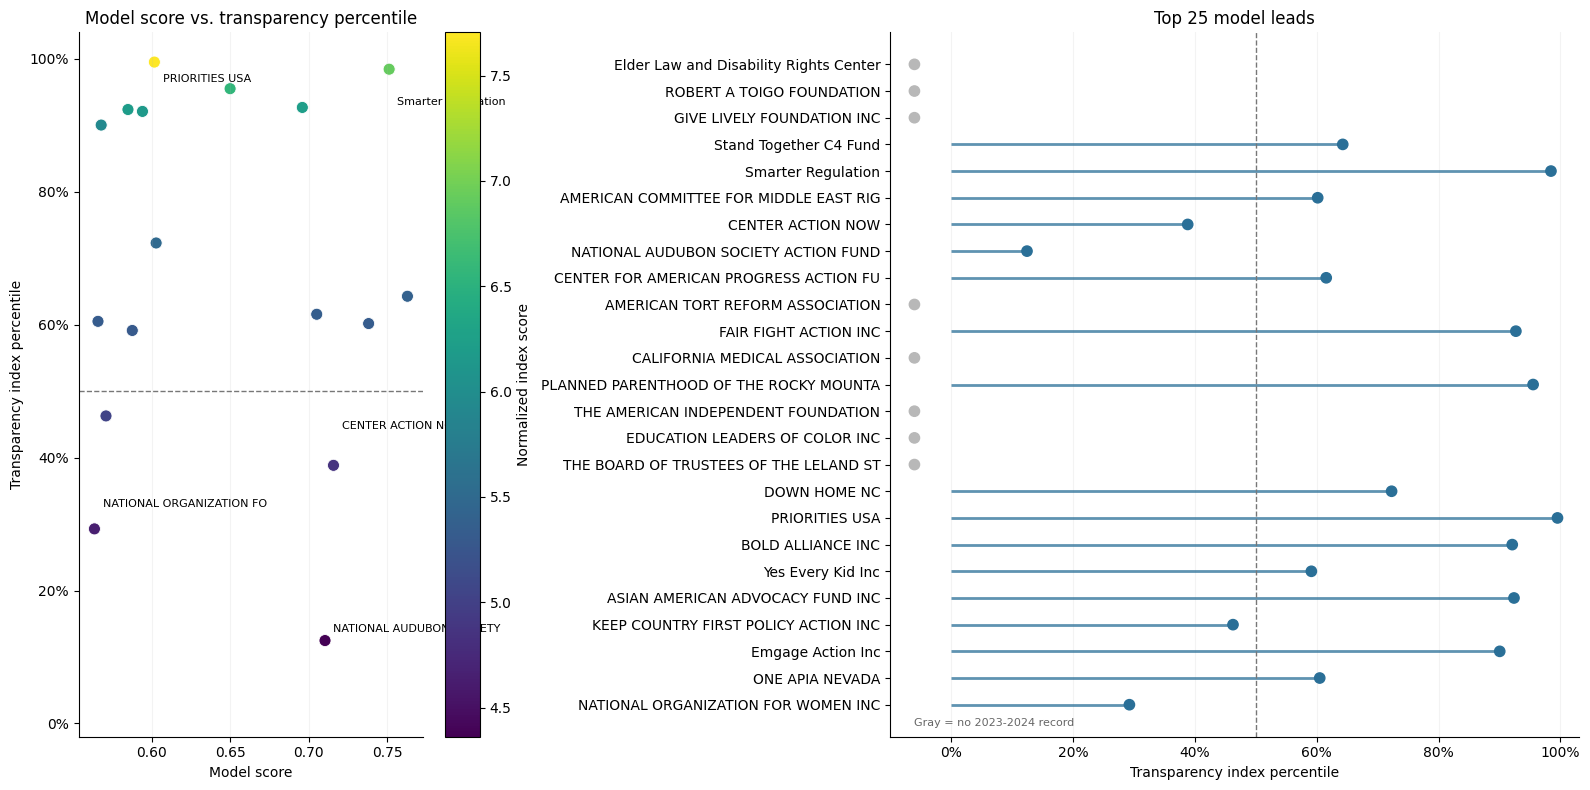

In [94]:
# Visual comparison of model rank and transparency index position.
import matplotlib.pyplot as plt

covered = model_lead_transparency[model_lead_transparency.has_transparency].copy()
plot_leads = model_lead_transparency.copy()
plot_leads["lead_label"] = plot_leads["name"].str.slice(0, 38)
plot_leads["plot_percentile"] = plot_leads.index_percentile.fillna(-0.06)

fig, axes = plt.subplots(
    1,
    2,
    figsize=(16, 8),
    gridspec_kw={"width_ratios": [1.0, 1.6]},
)

scatter = axes[0].scatter(
    covered.model_score,
    covered.index_percentile,
    c=covered.normalized_index_score,
    cmap="viridis",
    s=75,
    edgecolor="white",
    linewidth=0.6,
)
axes[0].axhline(0.5, color="#777777", linestyle="--", linewidth=1)
axes[0].set_title("Model score vs. transparency percentile")
axes[0].set_xlabel("Model score")
axes[0].set_ylabel("Transparency index percentile")
axes[0].set_ylim(-0.02, 1.04)
axes[0].yaxis.set_major_formatter(lambda value, _: f"{value:.0%}")

label_leads = pd.concat([
    covered.nlargest(2, "index_percentile"),
    covered.nsmallest(3, "index_percentile"),
]).drop_duplicates("ein")
high_index = 0
low_index = 0
for row in label_leads.itertuples(index=False):
    if row.index_percentile >= 0.5:
        offset = (6, -14 - high_index * 12)
        high_index += 1
    else:
        offset = (6, 6 + low_index * 10)
        low_index += 1
    axes[0].annotate(
        row.name[:24],
        (row.model_score, row.index_percentile),
        xytext=offset,
        textcoords="offset points",
        fontsize=8,
    )
fig.colorbar(scatter, ax=axes[0], label="Normalized index score")

rank_positions = np.arange(len(plot_leads))
point_colors = np.where(plot_leads.has_transparency, "#2A6F97", "#B8B8B8")
axes[1].hlines(
    rank_positions,
    xmin=0,
    xmax=plot_leads.plot_percentile.clip(lower=0),
    color=point_colors,
    linewidth=2,
    alpha=0.75,
)
axes[1].scatter(
    plot_leads.plot_percentile,
    rank_positions,
    color=point_colors,
    s=55,
    zorder=3,
)
axes[1].axvline(0.5, color="#777777", linestyle="--", linewidth=1)
axes[1].set_yticks(rank_positions, plot_leads.lead_label)
axes[1].invert_yaxis()
axes[1].set_xlim(-0.1, 1.03)
axes[1].set_xlabel("Transparency index percentile")
axes[1].set_title("Top 25 model leads")
axes[1].xaxis.set_major_formatter(lambda value, _: f"{value:.0%}")
axes[1].text(
    -0.06,
    len(plot_leads) - 0.2,
    "Gray = no 2023-2024 record",
    fontsize=8,
    color="#666666",
    ha="left",
)

for axis in axes:
    axis.spines[["top", "right"]].set_visible(False)
    axis.grid(axis="x", alpha=0.15)

fig.tight_layout()
plt.show()

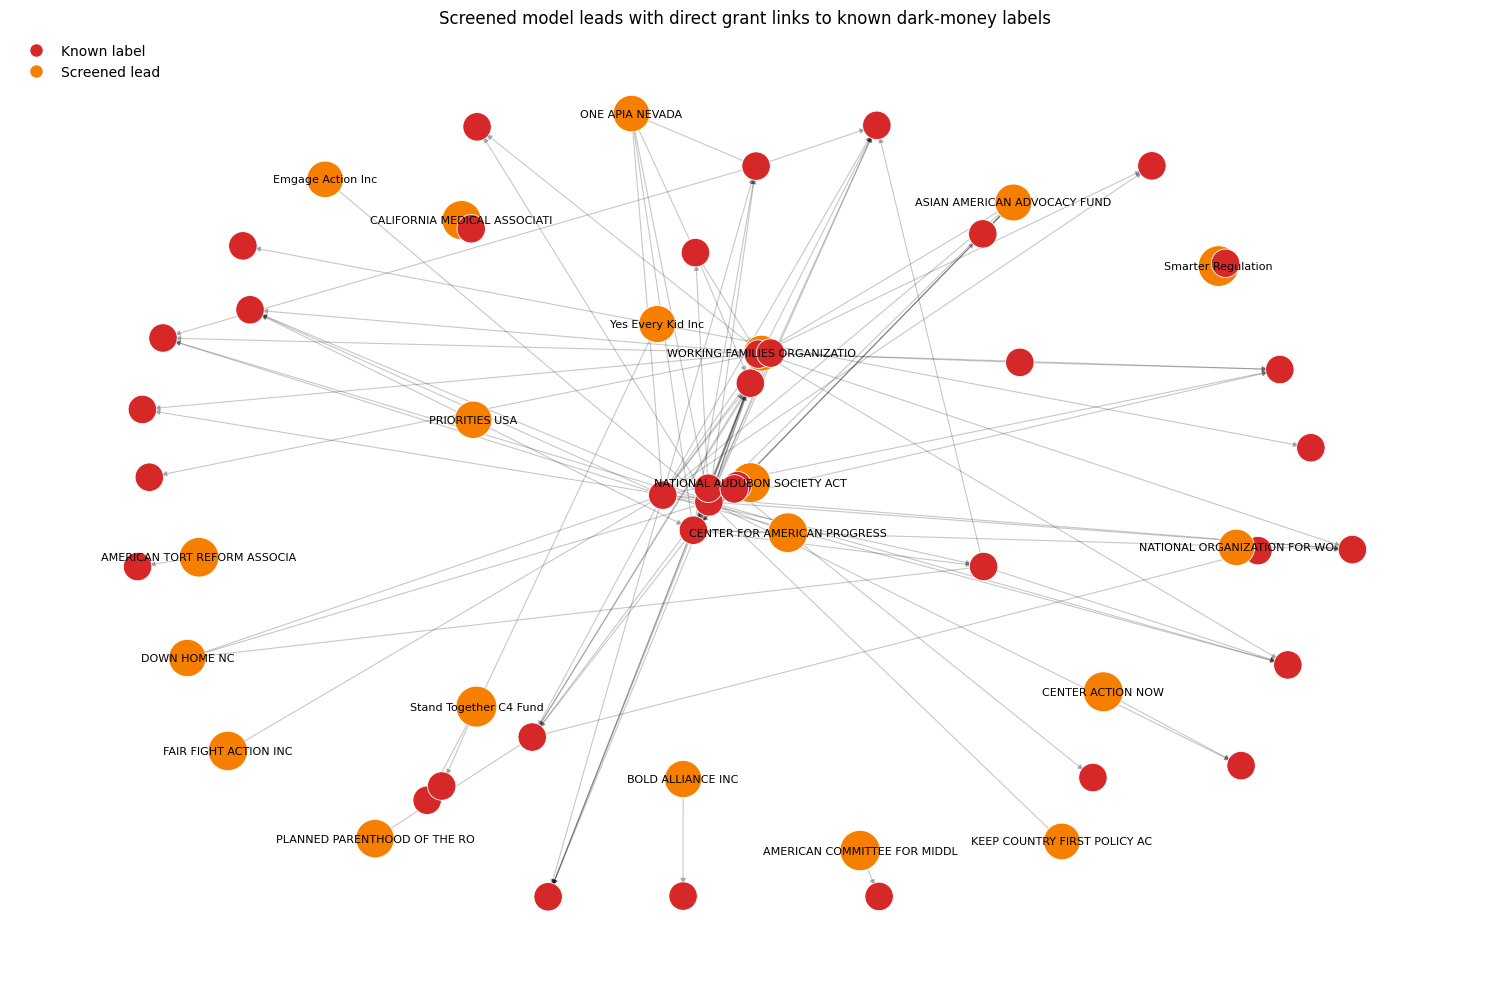

In [95]:
# Direct links between screened leads and known labels, sized by model probability.
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

name_of = M.set_index("ein").name.to_dict()
prob_of = M.set_index("ein").score.to_dict()
top_leads = set(filtered_leads.head(20).ein)

keep = set(top_leads)
for lead in top_leads:
    keep.update(neighbor for neighbor in G.predecessors(lead) if neighbor in seed_set)
    keep.update(neighbor for neighbor in G.successors(lead) if neighbor in seed_set)
Hp = G.subgraph(keep).copy()
Hp.remove_nodes_from([node for node in list(Hp.nodes) if Hp.degree(node) == 0])

pos = nx.spring_layout(Hp, k=0.9, seed=2, weight="amt")
colors = ["#D62828" if node in seed_set else "#F77F00" for node in Hp.nodes]
sizes = [420 if node in seed_set else 180 + 900 * prob_of.get(node, 0.0) for node in Hp.nodes]

fig, ax = plt.subplots(figsize=(15, 10))
nx.draw_networkx_edges(Hp, pos, alpha=0.22, width=0.8, arrows=True, arrowsize=8, ax=ax)
nx.draw_networkx_nodes(
    Hp, pos, node_size=sizes, node_color=colors,
    edgecolors="white", linewidths=0.6, ax=ax,
)
nx.draw_networkx_labels(
    Hp,
    pos,
    labels={node: name_of.get(node, node)[:28] for node in top_leads if node in Hp},
    font_size=8,
    ax=ax,
)
ax.legend(
    handles=[
        Line2D([0], [0], marker="o", color="w", markerfacecolor="#D62828", markersize=10, label="Known label"),
        Line2D([0], [0], marker="o", color="w", markerfacecolor="#F77F00", markersize=10, label="Screened lead"),
    ],
    loc="upper left",
    frameon=False,
)
ax.set_title("Screened model leads with direct grant links to known dark-money labels")
ax.axis("off")
plt.tight_layout()
plt.show()

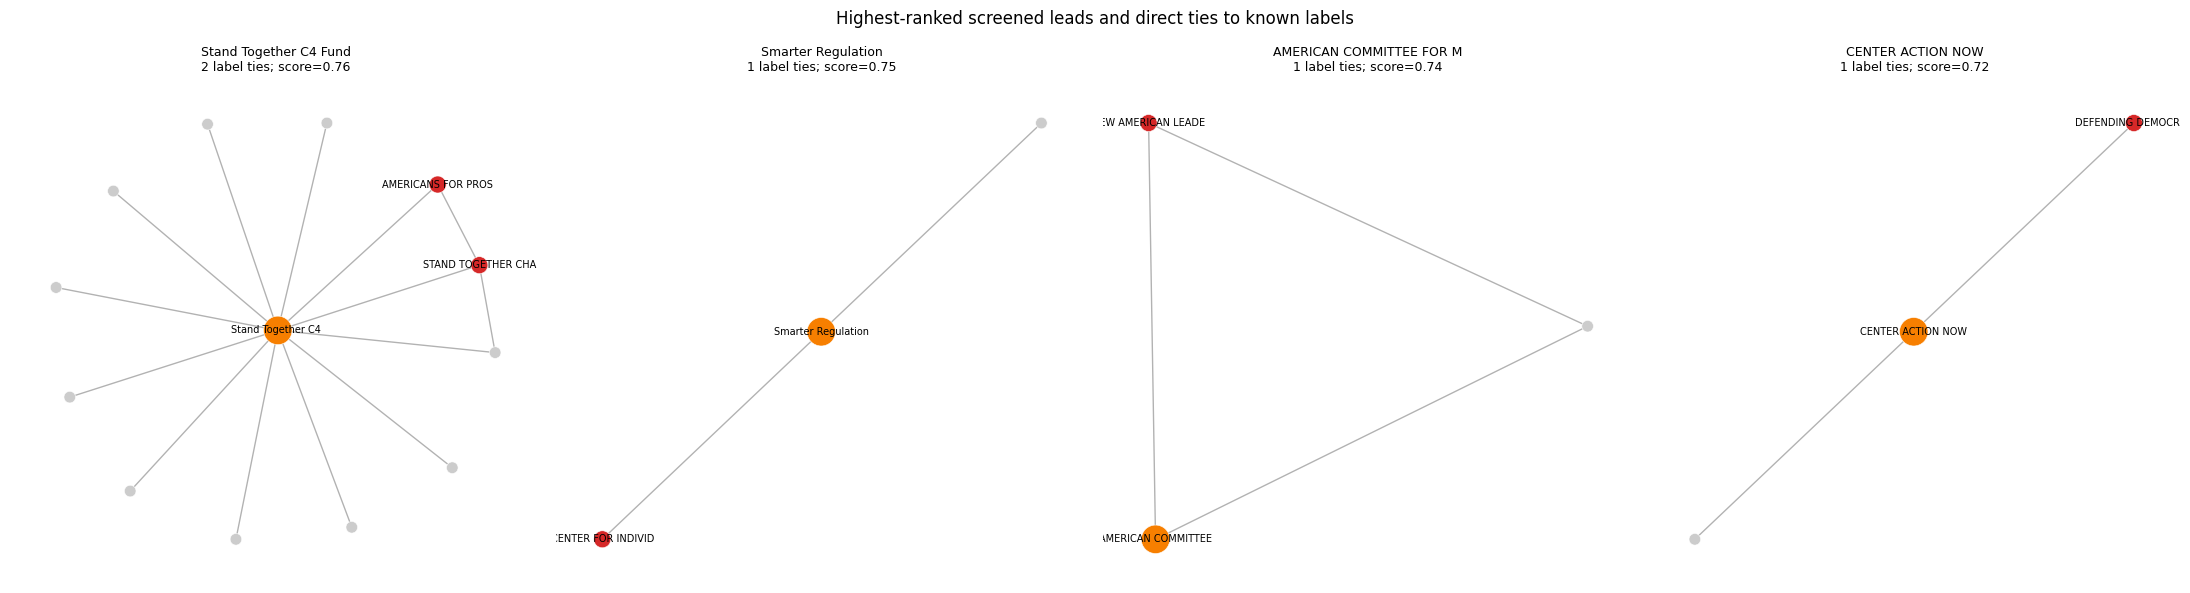

In [96]:
# Ego close-ups for the highest-ranked screened leads and their direct grant ties.
top_leads_list = filtered_leads.head(4).ein.tolist()
Gu = G.to_undirected()
fig, axes = plt.subplots(1, len(top_leads_list), figsize=(22, 6))
for ax, center in zip(axes, top_leads_list):
    ego = nx.ego_graph(Gu, center, radius=1)
    posE = nx.spring_layout(ego, seed=3)
    colors = ["#D62828" if node in seed_set else "#F77F00" if node == center else "#CCCCCC" for node in ego.nodes]
    sizes = [420 if node == center else 150 if node in seed_set else 70 for node in ego.nodes]
    nx.draw_networkx_edges(ego, posE, alpha=0.3, ax=ax)
    nx.draw_networkx_nodes(
        ego, posE, node_color=colors, node_size=sizes,
        edgecolors="white", linewidths=0.4, ax=ax,
    )
    nx.draw_networkx_labels(
        ego,
        posE,
        font_size=7,
        ax=ax,
        labels={
            node: name_of.get(node, node)[:18]
            for node in ego.nodes
            if node == center or node in seed_set
        },
    )
    seed_ties = sum(1 for neighbor in ego.neighbors(center) if neighbor in seed_set)
    ax.set_title(
        f"{name_of.get(center, center)[:24]}\n"
        f"{seed_ties} label ties; score={prob_of.get(center, 0):.2f}",
        fontsize=9,
    )
    ax.axis("off")
fig.suptitle("Highest-ranked screened leads and direct ties to known labels", fontsize=12)
plt.tight_layout()
plt.show()

## Organization profiles from K-means clustering

K-means provides an unsupervised view of organizations with similar network and behavioral characteristics. Clusters are built without seed labels, model scores, or personalized PageRank proximity. The number of clusters is selected by silhouette score, and principal component analysis is used only to display the resulting groups in two dimensions.

Known dark-money organizations are overlaid after clustering to show whether particular profiles contain a higher concentration of labeled examples.

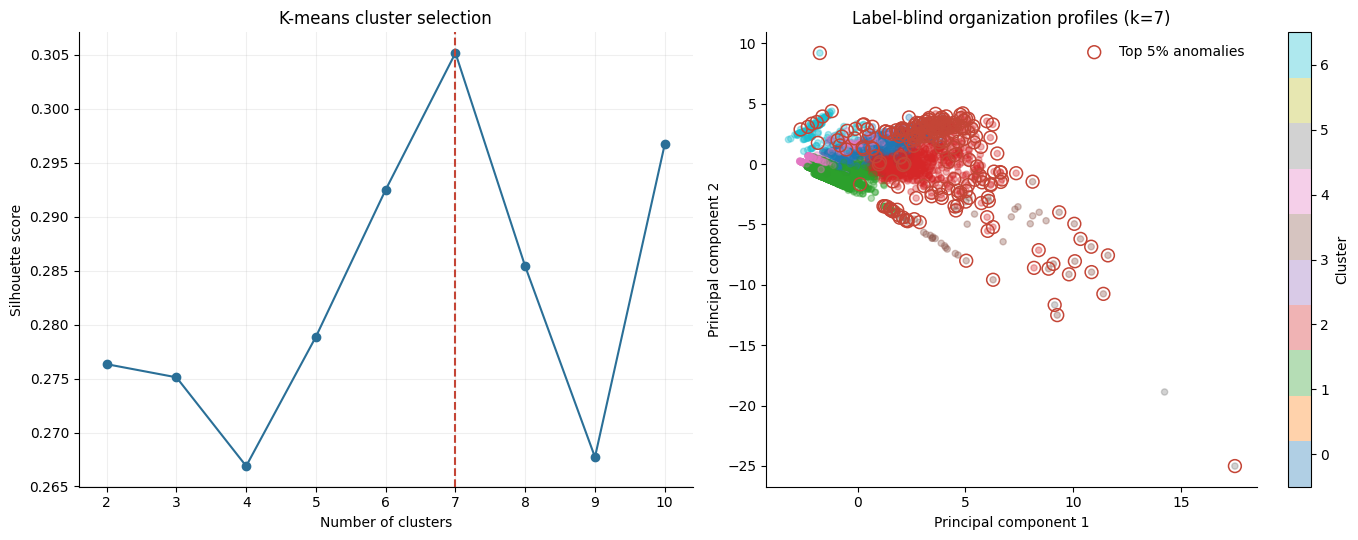

Selected k=7 with silhouette score 0.305


,organizations,anomalies,median_log_received,median_log_granted,median_global_pagerank
cluster,,,,,
0,782,24,14.496,11.435,2.34e-06
1,"2,010",11,12.994,0.000,2.12e-06
2,920,129,16.222,15.814,3.01e-06
3,52,29,20.925,16.424,4.50e-05
4,501,11,11.093,0.000,2.07e-06
5,3,2,22.247,24.290,2.03e-05
6,154,16,0.000,14.743,2.07e-06



Blind anomaly threshold: top 5% by centroid distance
Anomalies selected: 222 of 4,422
OpenSecrets prevalence in full pool: 265/4,422 (6.0%)
OpenSecrets matches among anomalies: 31/222 (14.0%)
Recall of OpenSecrets labels: 11.7%
OpenSecrets enrichment among anomalies: 2.33x


,cluster,ein,name,anomaly_distance,in_opensecrets
0,6,850784793,Marble Freedom Trust,64.323,False
1,2,232888152,VANGUARD CHARITABLE ENDOWMENT PROGRAM,20.536,False
2,5,110303001,FIDELITY INVESTMENTS CHARITABLE GIFT FUN,16.809,False
3,2,237825575,NATIONAL PHILANTHROPIC TRUST,16.690,False
4,5,810739440,AMERICAN ONLINE GIVING FOUNDATION INC,15.909,False
5,3,581493949,NATL CHRISTIAN CHARITABLE FDN INC,15.861,False
6,3,530196605,American National Red Cross & Its Constituent Chapters and Branches,14.835,False
7,2,527082731,MORGAN STANLEY GLOBAL IMPACT FUNDING TRUST INC,12.802,False
8,2,450931286,PAYPAL CHARITABLE GIVING FUND,11.488,False
9,2,431634280,CHARITIES AID FOUNDATION AMERICA,10.893,False


In [97]:
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Keep the clustering label-blind: no seed labels, model scores, PPR proximity,
# or political-neighbor features derived using seed exclusions.
cluster_features = STRUCTB + BEHAVB
cluster_frame = M[["ein", "name"] + cluster_features].copy()
cluster_matrix = StandardScaler().fit_transform(
    cluster_frame[cluster_features].replace([np.inf, -np.inf], np.nan).fillna(0)
)

silhouette_scores = {}
cluster_models = {}
for cluster_count in range(2, 11):
    model = KMeans(n_clusters=cluster_count, random_state=0, n_init=20)
    labels = model.fit_predict(cluster_matrix)
    silhouette_scores[cluster_count] = silhouette_score(cluster_matrix, labels)
    cluster_models[cluster_count] = model

best_cluster_count = max(silhouette_scores, key=silhouette_scores.get)
best_cluster_model = cluster_models[best_cluster_count]
cluster_labels = best_cluster_model.labels_
cluster_frame["cluster"] = cluster_labels
M["cluster"] = cluster_labels

# Distance from the assigned centroid is the unsupervised anomaly score.
assigned_centroids = best_cluster_model.cluster_centers_[cluster_labels]
cluster_frame["anomaly_distance"] = np.linalg.norm(
    cluster_matrix - assigned_centroids,
    axis=1,
)
ANOMALY_FRACTION = 0.05
anomaly_cutoff = cluster_frame["anomaly_distance"].quantile(1 - ANOMALY_FRACTION)
cluster_frame["is_anomaly"] = cluster_frame["anomaly_distance"] >= anomaly_cutoff

cluster_summary = (
    cluster_frame.groupby("cluster")
    .agg(
        organizations=("ein", "size"),
        anomalies=("is_anomaly", "sum"),
        median_log_received=("log_received", "median"),
        median_log_granted=("log_granted_out", "median"),
        median_global_pagerank=("global_pr", "median"),
    )
)

embedding = PCA(n_components=2).fit_transform(cluster_matrix)
cluster_frame["pc1"] = embedding[:, 0]
cluster_frame["pc2"] = embedding[:, 1]

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))
axes[0].plot(
    list(silhouette_scores),
    list(silhouette_scores.values()),
    marker="o",
    color="#2A6F97",
)
axes[0].axvline(best_cluster_count, color="#C44536", linestyle="--", linewidth=1.5)
axes[0].set_title("K-means cluster selection")
axes[0].set_xlabel("Number of clusters")
axes[0].set_ylabel("Silhouette score")
axes[0].set_xticks(list(silhouette_scores))
axes[0].grid(alpha=0.2)

cluster_scatter = axes[1].scatter(
    cluster_frame.pc1,
    cluster_frame.pc2,
    c=cluster_frame.cluster,
    cmap="tab10",
    vmin=-0.5,
    vmax=best_cluster_count - 0.5,
    s=20,
    alpha=0.35,
)
anomaly_points = cluster_frame[cluster_frame.is_anomaly]
axes[1].scatter(
    anomaly_points.pc1,
    anomaly_points.pc2,
    facecolors="none",
    edgecolors="#C44536",
    s=85,
    linewidth=1.1,
    label=f"Top {ANOMALY_FRACTION:.0%} anomalies",
)
axes[1].set_title(f"Label-blind organization profiles (k={best_cluster_count})")
axes[1].set_xlabel("Principal component 1")
axes[1].set_ylabel("Principal component 2")
axes[1].legend(frameon=False, loc="best")
fig.colorbar(
    cluster_scatter,
    ax=axes[1],
    ticks=range(best_cluster_count),
    label="Cluster",
)

for axis in axes:
    axis.spines[["top", "right"]].set_visible(False)

fig.tight_layout()
plt.show()

print(
    f"Selected k={best_cluster_count} with silhouette score "
    f"{silhouette_scores[best_cluster_count]:.3f}"
)
display(
    cluster_summary.style.format({
        "organizations": "{:,.0f}",
        "anomalies": "{:,.0f}",
        "median_log_received": "{:.3f}",
        "median_log_granted": "{:.3f}",
        "median_global_pagerank": "{:.2e}",
    })
)

# Freeze the anomaly set before adding the external OpenSecrets label.
blind_anomalies = (
    cluster_frame.loc[
        cluster_frame.is_anomaly,
        ["cluster", "ein", "name", "anomaly_distance"],
    ]
    .sort_values("anomaly_distance", ascending=False)
    .reset_index(drop=True)
)
blind_anomalies["in_opensecrets"] = blind_anomalies["ein"].isin(seed_set)

pool_opensecrets = int(cluster_frame["ein"].isin(seed_set).sum())
anomaly_opensecrets = int(blind_anomalies.in_opensecrets.sum())
pool_rate = pool_opensecrets / len(cluster_frame)
anomaly_rate = anomaly_opensecrets / len(blind_anomalies)
anomaly_recall = anomaly_opensecrets / pool_opensecrets if pool_opensecrets else 0.0
enrichment = anomaly_rate / pool_rate if pool_rate else np.nan

print(f"\nBlind anomaly threshold: top {ANOMALY_FRACTION:.0%} by centroid distance")
print(f"Anomalies selected: {len(blind_anomalies):,} of {len(cluster_frame):,}")
print(f"OpenSecrets prevalence in full pool: {pool_opensecrets:,}/{len(cluster_frame):,} ({pool_rate:.1%})")
print(f"OpenSecrets matches among anomalies: {anomaly_opensecrets:,}/{len(blind_anomalies):,} ({anomaly_rate:.1%})")
print(f"Recall of OpenSecrets labels: {anomaly_recall:.1%}")
print(f"OpenSecrets enrichment among anomalies: {enrichment:.2f}x")

display(
    blind_anomalies.head(25).style.format({
        "anomaly_distance": "{:.3f}",
    })
)

### Blind anomaly check against the dark-money labels

The clustering uses structural and behavioral features only. Label membership, model scores, personalized PageRank proximity, and political-neighbor features are excluded. Organizations in the top 5% of centroid distance are selected as anomalies, and label membership is added only after that list is fixed.

The blind check found 31 labeled organizations among 222 anomalies. Labeled organizations account for 14.0% of the anomaly group, compared with 6.0% of the full candidate pool. This is a 2.33-fold enrichment, although the anomaly group recovers only 11.7% of all labeled organizations in the pool.

Many of the strongest anomalies are donor-advised funds, universities, large charities, and other institutions whose scale or network structure is unusual for their cluster. Centroid distance is therefore useful as a supporting review signal rather than a dark-money classification. The supervised model and direct political-network evidence remain more appropriate for ranking candidates.

## Held-out evaluation

Out-of-fold scores reduce training leakage, but a stricter test is also used. Forty percent of the known OpenSecrets seeds are removed from both model training and PageRank personalization. Their rankings against the hard-negative candidate pool indicate whether the model generalizes to unseen dark-money organizations rather than memorizing the labeled set.

In [98]:
# Hold out 40% of known seeds (never trained, never in PPR); can the model still rank them above background?
import numpy as np, pandas as pd
from sklearn.metrics import roc_auc_score, average_precision_score

nm_pool = dict(zip(M.ein, M.name))
seed_i = np.where(y == 1)[0]; neg_i = np.where(y == 0)[0]

def run_split(frac, rs):
    rng = np.random.default_rng(rs)
    hold = rng.choice(seed_i, size=max(1, int(frac * len(seed_i))), replace=False)
    train_seed = np.setdiff1d(seed_i, hold)
    pv = prox([nodes[i] for i in train_seed])                 # PPR proximity from TRAIN seeds only (leak-free)
    Xall = np.column_stack([Xbase, pv])
    train_rows = np.concatenate([train_seed, neg_i])          # held-out seeds excluded from training
    m = GBC().fit(Xall[train_rows], y[train_rows])
    sc = m.predict_proba(Xall)[:, 1]
    ev = np.concatenate([hold, neg_i]); ye = np.concatenate([np.ones(len(hold)), np.zeros(len(neg_i))])
    order = ev[np.argsort(-sc[ev])]; rankmap = {n: r for r, n in enumerate(order, 1)}
    rec = {k: float(np.mean([rankmap[i] <= k for i in hold])) for k in (50, 100, 200)}
    return hold, sc, rankmap, roc_auc_score(ye, sc[ev]), average_precision_score(ye, sc[ev]), rec

FRAC = 0.40
res = [run_split(FRAC, rs) for rs in range(5)]
aucs = [r[3] for r in res]; aps = [r[4] for r in res]
r50 = [r[5][50] for r in res]; r100 = [r[5][100] for r in res]; r200 = [r[5][200] for r in res]
ncand = len(neg_i) + int(FRAC * len(seed_i))
print(f"Hold out {int(FRAC*len(seed_i))}/{len(seed_i)} known dark-money orgs — never trained, never seed the PPR.")
print(f"Averaged over 5 random splits, held-out orgs vs {len(neg_i):,} hard negatives (pool ~{ncand:,}):")
print(f"  ROC-AUC   {np.mean(aucs):.3f} ± {np.std(aucs):.3f}")
print(f"  PR-AUC    {np.mean(aps):.3f} ± {np.std(aps):.3f}  (random baseline ~{len(seed_i)*FRAC/ncand:.3f})")
print(f"  recall@50 {np.mean(r50):.2f}   recall@100 {np.mean(r100):.2f}   recall@200 {np.mean(r200):.2f}")

# One split in detail: which unseen dark-money orgs did the model catch vs miss?
hold, sc, rankmap, auc, ap, rec = res[0]
val = (pd.DataFrame({"ein": [nodes[i] for i in hold], "name": [nm_pool.get(nodes[i], nodes[i]) for i in hold],
                     "score": sc[hold], "rank_of_pool": [rankmap[i] for i in hold]})
       .sort_values("score", ascending=False).reset_index(drop=True))
print(f"\nSplit 0 (AUC {auc:.3f}) — {len(hold)} unseen dark-money orgs, median score "
      f"{np.median(sc[hold]):.3f} vs negatives {np.median(sc[neg_i]):.3f}:")
display(val)


Hold out 106/265 known dark-money orgs — never trained, never seed the PPR.
Averaged over 5 random splits, held-out orgs vs 4,157 hard negatives (pool ~4,263):
  ROC-AUC   0.908 ± 0.011
  PR-AUC    0.358 ± 0.030  (random baseline ~0.025)
  recall@50 0.23   recall@100 0.34   recall@200 0.46

Split 0 (AUC 0.915) — 106 unseen dark-money orgs, median score 0.124 vs negatives 0.005:


,ein,name,score,rank_of_pool
0,360727175,AMERICAN MEDICAL ASSOCIATION,0.999952,1
1,880359303,NATIONAL ASSOCIATION OF HOME BUILDERS OF THE U...,0.999896,2
2,474368320,MAJORITY FORWARD,0.959424,3
3,541916980,CENTER FOR INDIVIDUAL FREEDOM,0.943394,4
4,863689961,DEMAND JUSTICE,0.942181,5
...,...,...,...,...
101,237065623,CREDIT UNION NATIONAL ASSOCIATION INC,0.006756,1710
102,463508366,THE SEMINAR NETWORK INC,0.006535,1745
103,591391115,PLANNED PARENTHOOD OF SOUTH FLORIDA AND THE TR...,0.006034,1890
104,261598353,EVERYTOWN FOR GUN SAFETY SUPPORT FUND INC,0.005568,2043


## Political-neighbor feature ablation

This ablation measures the contribution of the political-neighbor feature. Earlier false negatives included trade groups such as credit-union leagues, chambers, and realtor associations, which often lack a typical conduit funding pattern. The feature measures the share of an organization's grant partners classified as 501(c)(4), 501(c)(6), or 527, with labeled seeds excluded. Performance is compared with and without the feature using out-of-fold cross-validation and held-out evaluation.

In [99]:
# Ablation: model WITHOUT political-neighbor (structural+behaviour) vs WITH it (Xbase, the full model).
import numpy as np
from sklearn.metrics import roc_auc_score, average_precision_score

Xno = M[STRUCTB + BEHAVB].fillna(0).values          # full model minus the political-neighbor block
cv = StratifiedKFold(5, shuffle=True, random_state=0)
def _oof(Xb):
    oof = np.zeros(len(nodes))
    for tr, te in cv.split(Xb, y):
        tp = [nodes[i] for i in tr if y[i] == 1]
        Xp = np.column_stack([Xb, prox(tp)])
        oof[te] = GBC().fit(Xp[tr], y[tr]).predict_proba(Xp[te])[:, 1]
    return oof
print(f"{'feature set':34s} {'OOF ROC-AUC':>11} {'OOF PR-AUC':>10}")
for tag, Xb in [("PPR + base", Xno), ("PPR + base + political-neighbor", Xbase)]:
    o = _oof(Xb)
    print(f"{tag:34s} {roc_auc_score(y, o):>11.3f} {average_precision_score(y, o):>10.3f}")

seed_i = np.where(y == 1)[0]; neg_i = np.where(y == 0)[0]
def _holdout(Xb, frac=0.40):
    aucs, recs = [], []
    for rs in range(5):
        rng = np.random.default_rng(rs)
        hold = rng.choice(seed_i, size=int(frac * len(seed_i)), replace=False)
        tr_seed = np.setdiff1d(seed_i, hold)
        Xall = np.column_stack([Xb, prox([nodes[i] for i in tr_seed])])
        rows = np.concatenate([tr_seed, neg_i])
        sc = GBC().fit(Xall[rows], y[rows]).predict_proba(Xall)[:, 1]
        ev = np.concatenate([hold, neg_i]); ye = np.concatenate([np.ones(len(hold)), np.zeros(len(neg_i))])
        aucs.append(roc_auc_score(ye, sc[ev]))
        order = ev[np.argsort(-sc[ev])]; rk = {n: r for r, n in enumerate(order, 1)}
        recs.append(np.mean([rk[i] <= 200 for i in hold]))
    return np.mean(aucs), np.std(aucs), np.mean(recs)
print()
for tag, Xb in [("base", Xno), ("+ political-neighbor", Xbase)]:
    a, s, r = _holdout(Xb)
    print(f"held-out  {tag:22s} ROC-AUC {a:.3f} ± {s:.3f}   recall@200 {r:.2f}")


feature set                        OOF ROC-AUC OOF PR-AUC
PPR + base                               0.896      0.299
PPR + base + political-neighbor          0.896      0.371

held-out  base                   ROC-AUC 0.903 ± 0.010   recall@200 0.40
held-out  + political-neighbor   ROC-AUC 0.908 ± 0.011   recall@200 0.46


## Contribution of LDA lobbying data

High-confidence client matches connect candidate-pool EINs to LDA records. Lobbying intensity is represented by the number of filings, distinct bills, and issue areas associated with each organization. An ablation test measures whether these features improve model performance, and the linkage is also reported as supporting evidence for ranked candidates.

In [100]:
# Bridge pool EINs -> LDA lobbying record via high_conf_matches; test as features + show as corroboration.
import numpy as np, pandas as pd
from sklearn.metrics import roc_auc_score, average_precision_score

conn.register("pool_eins", pd.DataFrame({"ein": nodes}))
lda = q("""
WITH pool AS (SELECT DISTINCT ein FROM pool_eins),
     ein_lda AS (SELECT DISTINCT ein, lda_key FROM high_conf_matches WHERE role = 'client'),
     cf AS (SELECT json_extract_string(raw_json, '$.client.id') AS lda_key, filing_uuid
            FROM lda_filings WHERE json_valid(raw_json)),
     agg AS (
        SELECT el.ein,
               COUNT(DISTINCT cf.filing_uuid) AS lda_n_filings,
               COUNT(DISTINCT (bl.bill_type, bl.bill_number)) AS lda_n_bills,
               COUNT(DISTINCT act.general_issue_code) AS lda_n_issues
        FROM ein_lda el JOIN cf USING (lda_key)
        LEFT JOIN lobbying_bill_links bl USING (filing_uuid)
        LEFT JOIN lda_lobbying_activities act USING (filing_uuid)
        GROUP BY el.ein)
SELECT p.ein,
       COALESCE(agg.lda_n_filings, 0) AS lda_n_filings,
       COALESCE(agg.lda_n_bills, 0)   AS lda_n_bills,
       COALESCE(agg.lda_n_issues, 0)  AS lda_n_issues,
       CASE WHEN agg.ein IS NOT NULL THEN 1 ELSE 0 END AS is_lda_client
FROM pool p LEFT JOIN agg USING (ein)
""")
Mlda = M.merge(lda, on="ein", how="left")
for c in ["lda_n_filings", "lda_n_bills", "lda_n_issues", "is_lda_client"]:
    Mlda[c] = Mlda[c].fillna(0)
Mlda["log_lda_bills"] = np.log1p(Mlda.lda_n_bills)
LDAF = ["is_lda_client", "log_lda_bills", "lda_n_issues"]

cov_pool = int((Mlda.is_lda_client == 1).sum())
cov_seed = int(((Mlda.is_lda_client == 1) & (y == 1)).sum())
print(f"LDA lobbying coverage in the pool: {cov_pool}/{len(nodes)} orgs are matched LDA clients "
      f"({cov_seed}/{int(y.sum())} seeds).")

Xlda = np.column_stack([Xbase, Mlda[LDAF].fillna(0).values])
cv = StratifiedKFold(5, shuffle=True, random_state=0)
def _oof(Xb):
    oof = np.zeros(len(nodes))
    for tr, te in cv.split(Xb, y):
        tp = [nodes[i] for i in tr if y[i] == 1]
        Xp = np.column_stack([Xb, prox(tp)])
        oof[te] = GBC().fit(Xp[tr], y[tr]).predict_proba(Xp[te])[:, 1]
    return oof
print(f"\n{'feature set':28s} {'OOF ROC-AUC':>11} {'OOF PR-AUC':>10}")
for tag, Xb in [("full model", Xbase), ("full model + LDA lobbying", Xlda)]:
    o = _oof(Xb)
    print(f"{tag:28s} {roc_auc_score(y, o):>11.3f} {average_precision_score(y, o):>10.3f}")

seed_i = np.where(y == 1)[0]; neg_i = np.where(y == 0)[0]
def _holdout(Xb, frac=0.40):
    aucs = []
    for rs in range(5):
        rng = np.random.default_rng(rs)
        hold = rng.choice(seed_i, size=int(frac * len(seed_i)), replace=False)
        tr_seed = np.setdiff1d(seed_i, hold)
        Xall = np.column_stack([Xb, prox([nodes[i] for i in tr_seed])])
        rows = np.concatenate([tr_seed, neg_i])
        sc = GBC().fit(Xall[rows], y[rows]).predict_proba(Xall)[:, 1]
        ev = np.concatenate([hold, neg_i]); ye = np.concatenate([np.ones(len(hold)), np.zeros(len(neg_i))])
        aucs.append(roc_auc_score(ye, sc[ev]))
    return np.mean(aucs), np.std(aucs)
print()
for tag, Xb in [("full model", Xbase), ("full model + LDA lobbying", Xlda)]:
    a, s = _holdout(Xb)
    print(f"held-out  {tag:26s} ROC-AUC {a:.3f} ± {s:.3f}")

# Practical use: LDA lobbying as corroboration on the current leads.
print("\nTop 15 leads with LDA lobbying corroboration:")
display(leads.head(15).merge(Mlda[["ein", "is_lda_client", "lda_n_bills", "lda_n_issues"]], on="ein", how="left")
        [["ein", "name", "score", "is_lda_client", "lda_n_bills", "lda_n_issues"]])


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

LDA lobbying coverage in the pool: 286/4422 orgs are matched LDA clients (54/265 seeds).

feature set                  OOF ROC-AUC OOF PR-AUC
full model                         0.896      0.371
full model + LDA lobbying          0.901      0.384

held-out  full model                 ROC-AUC 0.908 ± 0.011
held-out  full model + LDA lobbying  ROC-AUC 0.911 ± 0.009

Top 15 leads with LDA lobbying corroboration:


,ein,name,score,is_lda_client,lda_n_bills,lda_n_issues
0,814128457,Elder Law and Disability Rights Center,0.987932,0,0,0
1,133565420,ROBERT A TOIGO FOUNDATION,0.985787,0,0,0
2,810693451,GIVE LIVELY FOUNDATION INC,0.984445,0,0,0
3,883998455,Stand Together C4 Fund,0.763061,0,0,0
4,923566420,Smarter Regulation,0.751398,0,0,0
5,882513621,AMERICAN COMMITTEE FOR MIDDLE EAST RIGHTS,0.738311,0,0,0
6,844552289,CENTER ACTION NOW,0.715907,0,0,0
7,831280515,NATIONAL AUDUBON SOCIETY ACTION FUND,0.710504,1,8,6
8,300192708,CENTER FOR AMERICAN PROGRESS ACTION FUND,0.705213,1,18,22
9,521464785,AMERICAN TORT REFORM ASSOCIATION,0.702001,0,0,0


## Linking FEC Super PAC records

FEC committee records do not include EINs, so independent-expenditure-only committees (`committee_type = 'O'`) are linked to IRS organizations using normalized names, exact and near-name matching, and state agreement. The local FEC totals extract provides `committee_state` but no ZIP field. Near-name candidates require a blocked Jaro-Winkler similarity of at least 0.85, while final links require similarity of at least 0.90 and matching states.

This method can identify organizations and similarly named electoral arms, but it can also join unrelated organizations with similar names in the same state. The links are therefore corroborating evidence and require manual review rather than confirmed affiliations. Spending totals are restricted to the FEC cycle corresponding to the selected IRS years.

In [101]:
# FEC Super PAC linkage: exact and near-name matching with committee-state agreement.
import re
import numpy as np, pandas as pd

for _t in ("committees", "fec_disbursements"):
    conn.execute(f"""CREATE OR REPLACE VIEW {_t} AS
        SELECT * FROM read_parquet('{(ROOT / 'parquet_export' / _t / '*.parquet').as_posix()}', union_by_name=true)""")

# FEC totals use two-year election cycles. Map each selected IRS year to its
# corresponding cycle ending year (for example, 2023 and 2024 both map to 2024).
ANALYSIS_YEARS = tuple(sorted({int(year) for year in re.findall(r"\d{4}", YEARS)}))
FEC_CYCLES = tuple(sorted({year if year % 2 == 0 else year + 1 for year in ANALYSIS_YEARS}))
FEC_CYCLES_SQL = "(" + ", ".join(map(str, FEC_CYCLES)) + ")"
print(f"IRS analysis years: {ANALYSIS_YEARS}; corresponding FEC cycles: {FEC_CYCLES}")

# Type O is an independent-expenditure-only committee. The totals extract exposes
# committee_state in raw_json; ZIP is unavailable.
conn.execute("""
CREATE OR REPLACE TEMP TABLE fec_committees AS
SELECT committee_id,
       any_value(name) AS committee_name,
       norm_org(any_value(name)) AS normalized_name,
       any_value(committee_type) AS committee_type,
       any_value(party) AS party,
       max(UPPER(NULLIF(TRIM(json_extract_string(raw_json, '$.committee_state')), ''))) AS fec_state,
       NULL::VARCHAR AS fec_zip
FROM committees
WHERE name IS NOT NULL
  AND committee_type = 'O'
  AND json_valid(raw_json)
GROUP BY committee_id
""")

conn.execute(f"""
CREATE OR REPLACE TEMP TABLE fec_matches AS
WITH exact AS (
    SELECT fc.committee_id, fc.committee_name, fc.committee_type, fc.party,
           irs.ein, irs.irs_name, 1.0 AS name_similarity,
           (irs.irs_state = fc.fec_state AND fc.fec_state IS NOT NULL) AS state_agrees,
           FALSE AS zip_agrees
    FROM fec_committees fc JOIN irs_entities_addr irs USING (normalized_name)
),
near AS (
    SELECT fc.committee_id, fc.committee_name, fc.committee_type, fc.party,
           irs.ein, irs.irs_name,
           jaro_winkler_similarity(fc.normalized_name, irs.normalized_name) AS name_similarity,
           (irs.irs_state = fc.fec_state AND fc.fec_state IS NOT NULL) AS state_agrees,
           FALSE AS zip_agrees
    FROM fec_committees fc JOIN irs_entities_addr irs
      ON {name_block_on('fc.normalized_name', 'irs.normalized_name')}
     AND fc.normalized_name <> irs.normalized_name
    WHERE jaro_winkler_similarity(fc.normalized_name, irs.normalized_name) >= {NEAR_NAME_MIN_SIMILARITY}
)
SELECT * FROM exact UNION ALL SELECT * FROM near
""")

# Cycle totals are filtered to the election cycles that overlap the selected IRS years.
conn.execute(f"""
CREATE OR REPLACE TEMP TABLE fec_spend AS
SELECT committee_id,
       TRY_CAST(disbursement_date AS INTEGER) AS cycle,
       SUM(TRY_CAST(disbursement_amount AS DOUBLE)) AS disbursements,
       SUM(TRY_CAST(regexp_extract(disbursement_description, 'independent_expenditures=([0-9.]+)', 1) AS DOUBLE)) AS ie
FROM fec_disbursements
WHERE recipient_name = '__CYCLE_TOTALS__'
  AND TRY_CAST(disbursement_date AS INTEGER) IN {FEC_CYCLES_SQL}
GROUP BY committee_id, cycle
""")

fec_link = q(f"""
WITH ranked AS (
    SELECT m.*, {tier_case('name')} AS tier,
           ROW_NUMBER() OVER (PARTITION BY m.committee_id
                              ORDER BY state_agrees DESC, name_similarity DESC, ein) AS rn
    FROM fec_matches m
    WHERE name_similarity >= {HIGH_CONF_MIN} AND state_agrees
)
SELECT r.ein, r.irs_name, r.committee_id, r.committee_name, r.committee_type, r.party,
       ROUND(r.name_similarity, 4) AS name_similarity, r.tier, s.cycle,
       COALESCE(s.ie, 0) AS ie, COALESCE(s.disbursements, 0) AS disb
FROM ranked r
JOIN fec_spend s USING (committee_id)
WHERE r.rn = 1
""")
print(f"FEC Super PACs linked to IRS EINs for cycles {FEC_CYCLES} "
      f"(sim>={HIGH_CONF_MIN}, state agrees): "
      f"{fec_link.committee_id.nunique():,} committees -> {fec_link.ein.nunique():,} EINs")
print(fec_link.groupby(["cycle", "tier"]).size().to_string())

# Current labels and screened leads with a matched Super PAC, reported by cycle.
lead_eins = set(filtered_leads.head(50).ein)
dm = fec_link[fec_link.ein.isin(seed_set) | fec_link.ein.isin(lead_eins)].copy()
dm["cohort"] = np.where(dm.ein.isin(seed_set), "label", "screened lead")
dm["org"] = dm.ein.map(nm)
print("\nLabeled organizations and screened leads with a matched FEC Super PAC:")
display(dm.sort_values(["cycle", "ie"], ascending=[False, False])
        [["cycle", "org", "cohort", "committee_name", "committee_type", "party", "name_similarity", "tier", "ie", "disb"]].head(25))

IRS analysis years: (2023, 2024); corresponding FEC cycles: (2024,)
FEC Super PACs linked to IRS EINs for cycles (2024,) (sim>=0.9, state agrees): 396 committees -> 374 EINs
cycle  tier        
2024   name + state    396

Labeled organizations and screened leads with a matched FEC Super PAC:


,cycle,org,cohort,committee_name,committee_type,party,name_similarity,tier,ie,disb
199,2024,American Principles Project,label,AMERICAN PRINCIPLES PROJECT PAC,O,None,1.0000,name + state,7933282.25,12862572.49
89,2024,Care in Action Inc,screened lead,CARE IN ACTION PAC,O,None,1.0000,name + state,4501895.04,5210068.15
142,2024,Black Voters Matter Fund Inc,label,BLACK VOTERS MATTER ACTION PAC,O,None,0.9365,name + state,3623633.16,4310873.87
144,2024,WORKER POWER,label,WORKER POWER PAC,O,None,1.0000,name + state,2804390.03,10028516.68
344,2024,REPRODUCTIVE FREEDOM FOR ALL,label,REPRODUCTIVE FREEDOM FOR ALL FREEDOM FUND,O,None,0.9500,name + state,2638037.61,2915627.98
162,2024,In Union USA Action,label,IN UNION USA,O,None,0.9263,name + state,2061874.95,7483307.49
277,2024,CASA IN ACTION INC,label,CASA IN ACTION PAC,O,None,1.0000,name + state,1748702.01,3859637.08
107,2024,MONTANA HUNTERS AND ANGLERS ACTION,label,MONTANA HUNTERS AND ANGLERS LEADERSHIP FUND,O,None,0.9263,name + state,1063619.18,1284527.31
262,2024,WORKER POWER,label,WORKER POWER PAC FOR GEORGIA,O,None,0.9200,name + state,1030000.00,1030000.00
114,2024,NEVADA ADVOCATES FOR PLANNED,label,NEVADA ADVOCATES FOR PLANNED PARENTHOOD AFFILI...,O,None,0.9769,name + state,865721.68,873888.98


In [102]:
# FEC as a modeling signal (has_fec + log independent expenditures / disbursements) + corroboration on leads.
import numpy as np, pandas as pd
from sklearn.metrics import roc_auc_score, average_precision_score

fec_by_ein = (fec_link.groupby("ein")
              .agg(fec_n_committees=("committee_id", "nunique"),
                   fec_ie=("ie", "sum"), fec_disb=("disb", "sum")).reset_index())
fe = pd.DataFrame({"ein": nodes}).merge(fec_by_ein, on="ein", how="left").fillna(0)
fe["has_fec"] = (fe.fec_n_committees > 0).astype(int)
fe["log_fec_ie"] = np.log1p(fe.fec_ie); fe["log_fec_disb"] = np.log1p(fe.fec_disb)
FECF = ["has_fec", "log_fec_ie", "log_fec_disb"]
Xfec = np.column_stack([Xbase, fe[FECF].values])

cov_pool = int(fe.has_fec.sum()); cov_seed = int(((fe.has_fec == 1).values & (y == 1)).sum())
print(f"FEC committee coverage in the pool: {cov_pool}/{len(nodes)} orgs run a linked Super PAC "
      f"({cov_seed}/{int(y.sum())} seeds).")

cv = StratifiedKFold(5, shuffle=True, random_state=0)
def _oof(Xb):
    oof = np.zeros(len(nodes))
    for tr, te in cv.split(Xb, y):
        tp = [nodes[i] for i in tr if y[i] == 1]
        Xp = np.column_stack([Xb, prox(tp)])
        oof[te] = GBC().fit(Xp[tr], y[tr]).predict_proba(Xp[te])[:, 1]
    return oof
print(f"\n{'feature set':24s} {'OOF ROC-AUC':>11} {'OOF PR-AUC':>10}")
for tag, Xb in [("full model", Xbase), ("full model + FEC", Xfec)]:
    o = _oof(Xb)
    print(f"{tag:24s} {roc_auc_score(y, o):>11.3f} {average_precision_score(y, o):>10.3f}")

seed_i = np.where(y == 1)[0]; neg_i = np.where(y == 0)[0]
def _holdout(Xb, frac=0.40):
    aucs = []
    for rs in range(5):
        rng = np.random.default_rng(rs)
        hold = rng.choice(seed_i, size=int(frac * len(seed_i)), replace=False)
        tr_seed = np.setdiff1d(seed_i, hold)
        Xall = np.column_stack([Xb, prox([nodes[i] for i in tr_seed])])
        rows = np.concatenate([tr_seed, neg_i])
        sc = GBC().fit(Xall[rows], y[rows]).predict_proba(Xall)[:, 1]
        ev = np.concatenate([hold, neg_i]); ye = np.concatenate([np.ones(len(hold)), np.zeros(len(neg_i))])
        aucs.append(roc_auc_score(ye, sc[ev]))
    return np.mean(aucs), np.std(aucs)
print()
for tag, Xb in [("full model", Xbase), ("full model + FEC", Xfec)]:
    a, s = _holdout(Xb)
    print(f"held-out  {tag:20s} ROC-AUC {a:.3f} ± {s:.3f}")

print("\nTop 15 leads with FEC electoral-arm corroboration ($ independent expenditures / disbursements):")
display(leads.head(15).merge(fe[["ein", "has_fec", "fec_ie", "fec_disb"]], on="ein", how="left")
        [["ein", "name", "score", "has_fec", "fec_ie", "fec_disb"]])


FEC committee coverage in the pool: 69/4422 orgs run a linked Super PAC (27/265 seeds).

feature set              OOF ROC-AUC OOF PR-AUC
full model                     0.896      0.371
full model + FEC               0.896      0.383

held-out  full model           ROC-AUC 0.908 ± 0.011
held-out  full model + FEC     ROC-AUC 0.906 ± 0.010

Top 15 leads with FEC electoral-arm corroboration ($ independent expenditures / disbursements):


,ein,name,score,has_fec,fec_ie,fec_disb
0,814128457,Elder Law and Disability Rights Center,0.987932,0,0.0,0.0
1,133565420,ROBERT A TOIGO FOUNDATION,0.985787,0,0.0,0.0
2,810693451,GIVE LIVELY FOUNDATION INC,0.984445,0,0.0,0.0
3,883998455,Stand Together C4 Fund,0.763061,0,0.0,0.0
4,923566420,Smarter Regulation,0.751398,0,0.0,0.0
5,882513621,AMERICAN COMMITTEE FOR MIDDLE EAST RIGHTS,0.738311,0,0.0,0.0
6,844552289,CENTER ACTION NOW,0.715907,0,0.0,0.0
7,831280515,NATIONAL AUDUBON SOCIETY ACTION FUND,0.710504,0,0.0,0.0
8,300192708,CENTER FOR AMERICAN PROGRESS ACTION FUND,0.705213,0,0.0,0.0
9,521464785,AMERICAN TORT REFORM ASSOCIATION,0.702001,0,0.0,0.0
